In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
#mpl.rcParams['font.family'] = 'Calibri'

import seaborn as sb
from statannot import add_stat_annotation
from scipy.stats import mannwhitneyu

import matplotlib.patches as mpatches
from scipy.stats import wilcoxon, ttest_ind
from scipy.stats import pearsonr

from scipy import stats
import seaborn as sns
import matplotlib.colors as mcolors
import matplotlib.patheffects as path_effects

from IPython.display import display
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.expand_frame_repr', True)
import warnings
warnings.filterwarnings('ignore')

path = '/home/ripper8/projects/working_data/GRNv3knockouts/analysis'
experiments = ['reg10m2', 'reg2m2']
exp_labels = ['R10','R2']
print('ok')

ok


In [66]:
traits = ['disp_y', 'distance', 'extremities_prop', 'symmetry', 'proportion', 
          'coverage', 'extensiveness_prop', 'branching_prop','modules_count','hinge_prop']

traits_labels = ['fitness', 'growth', 'limbs', 'symmetry', 'proportion', 
              'coverage', 'limbs length', 'branching','size','hinges']

df_traits = {}
df_categ_traits = {}

for trait in traits:
    print('>>>>>',trait)
    df_traits[trait] = pd.read_csv(f'{path}/knockouts/data/effects_{trait}.csv')
    df_traits[trait]['epistasis_percent'] = df_traits[trait]['positive'] + df_traits[trait]['negative']
    df_traits[trait]['avg_negative']  = df_traits[trait]['avg_negative'] * -1

    df_categ_traits[trait] = pd.read_csv(f'{path}/knockouts/data/effectscateg_{trait}.csv')
print('ok')
   

>>>>> disp_y
>>>>> distance
>>>>> extremities_prop
>>>>> symmetry
>>>>> proportion
>>>>> coverage
>>>>> extensiveness_prop
>>>>> branching_prop
>>>>> modules_count
>>>>> hinge_prop
ok


In [46]:

keys = ['experiment_name', 'run', 'gen', 'individual_id']

df_complexity = pd.read_csv(f'{path}/complexity/complexity.csv').drop(columns=['geno_size'])
df_complexity_net = pd.read_csv(f'{path}/complexity/complexity_net.csv')
df_complexity_all = pd.merge(df_complexity, df_complexity_net, on=keys, how='inner')

df_complexity_all['interactions_density'] = df_complexity_all['complexity_net'] / df_complexity_all['n_genes']
print('ok')

ok


>>>>> disp_y
>> 0


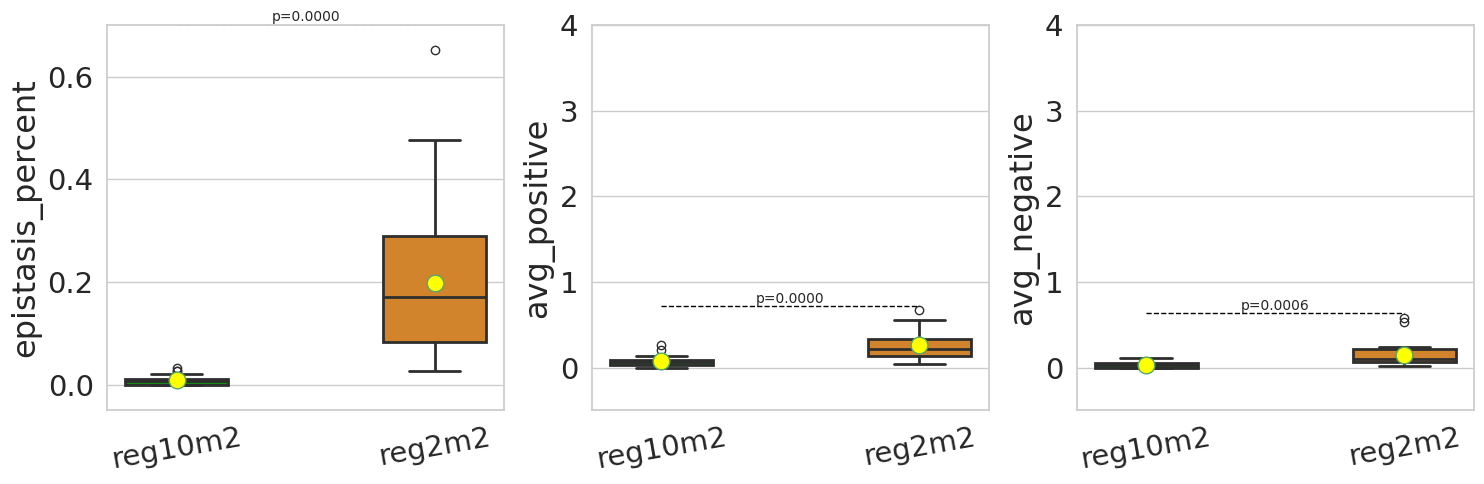

>> 100


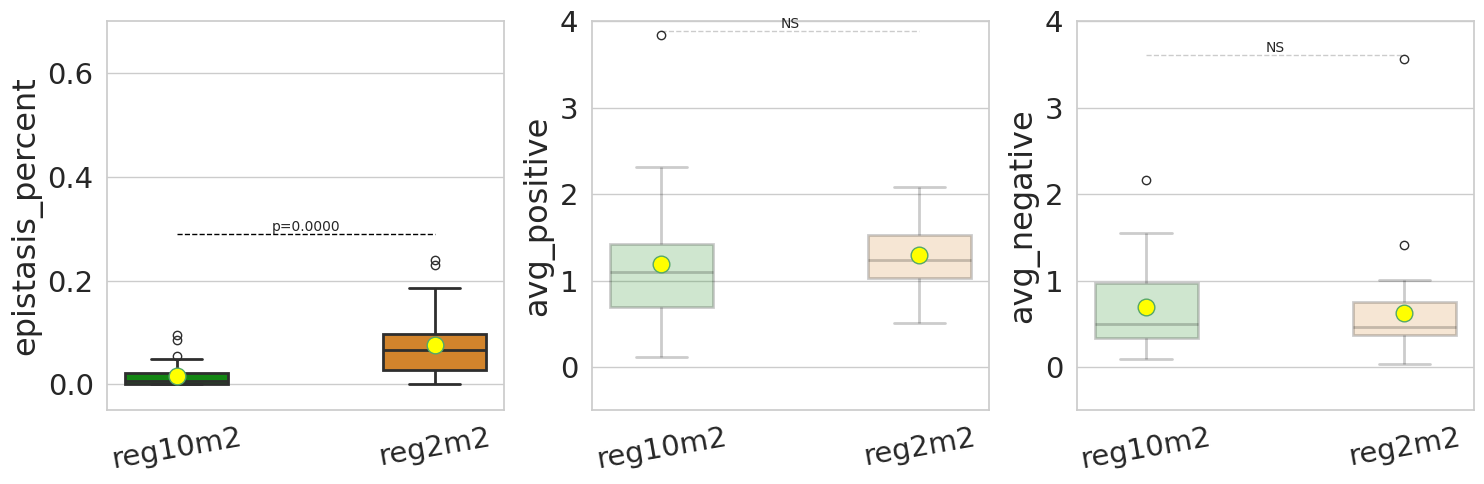

>>>>> distance
>> 0


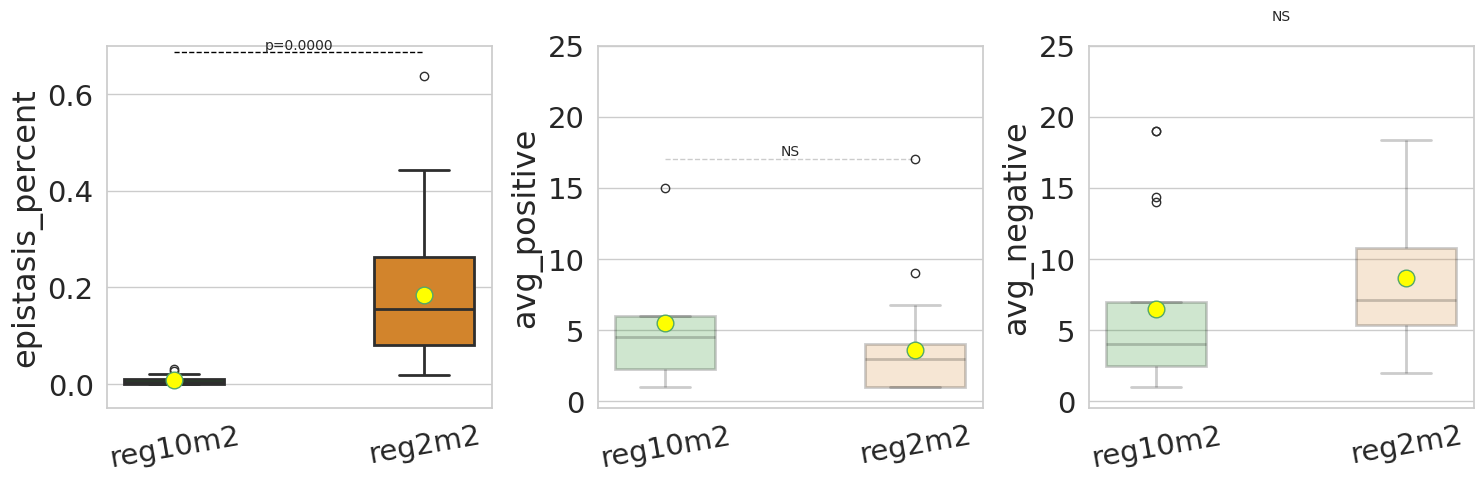

>> 100


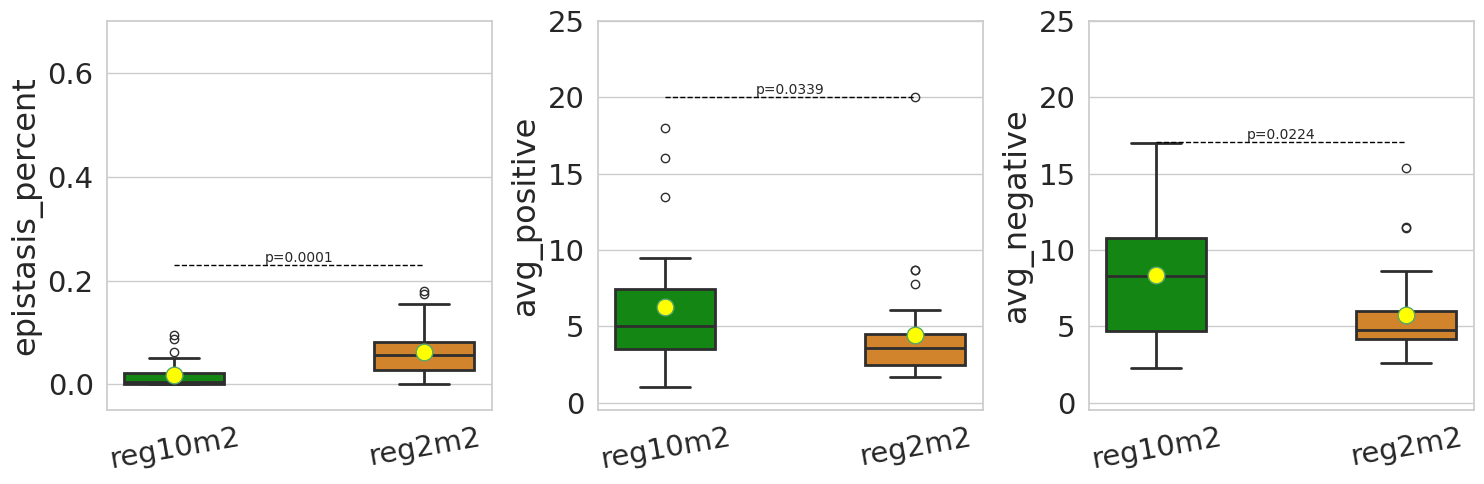

>>>>> extremities_prop
>> 0


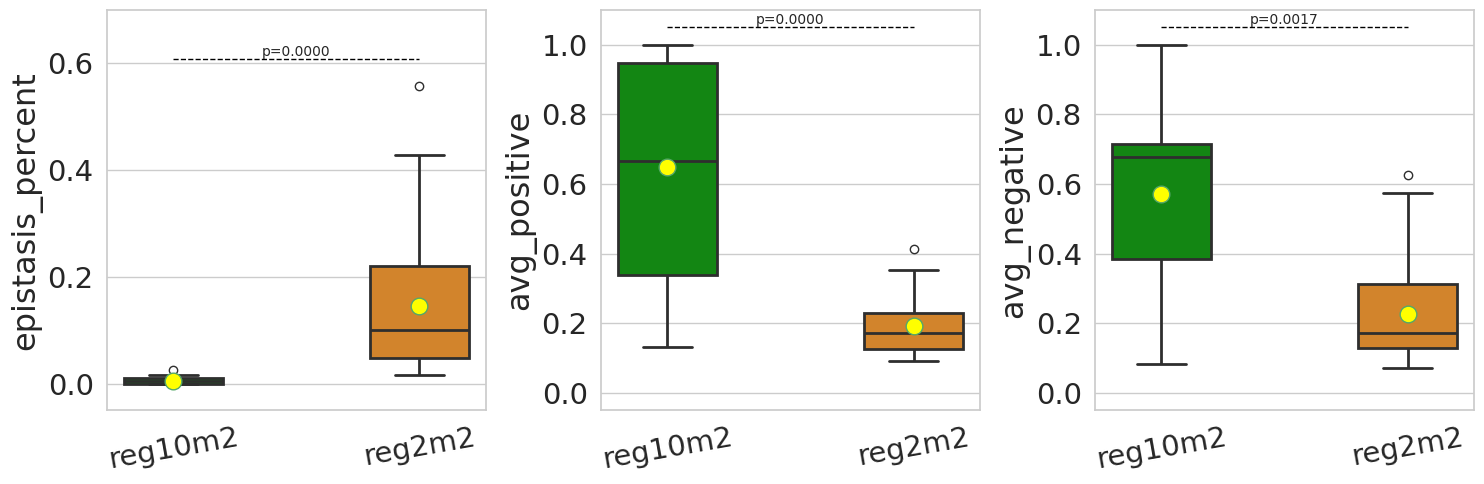

>> 100


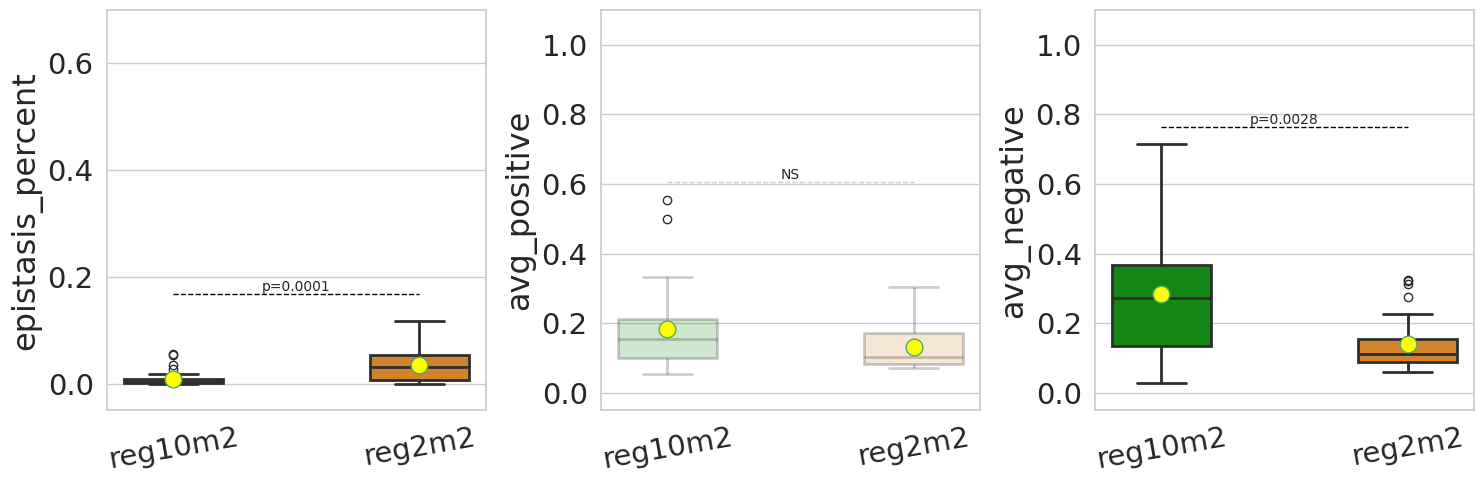

>>>>> symmetry
>> 0


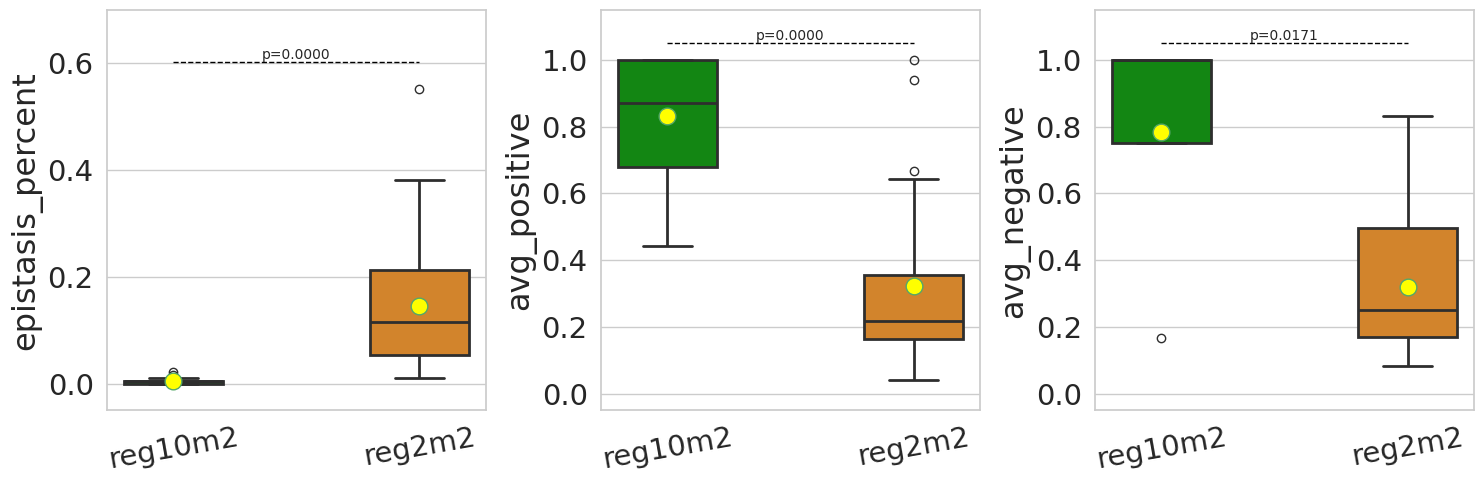

>> 100


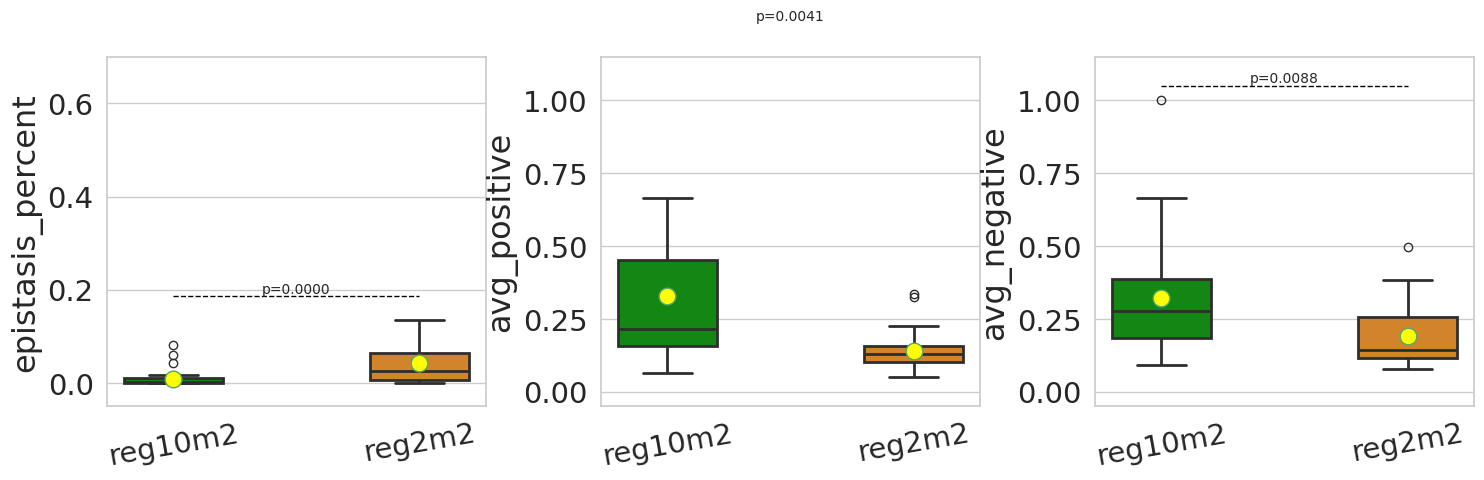

>>>>> proportion
>> 0


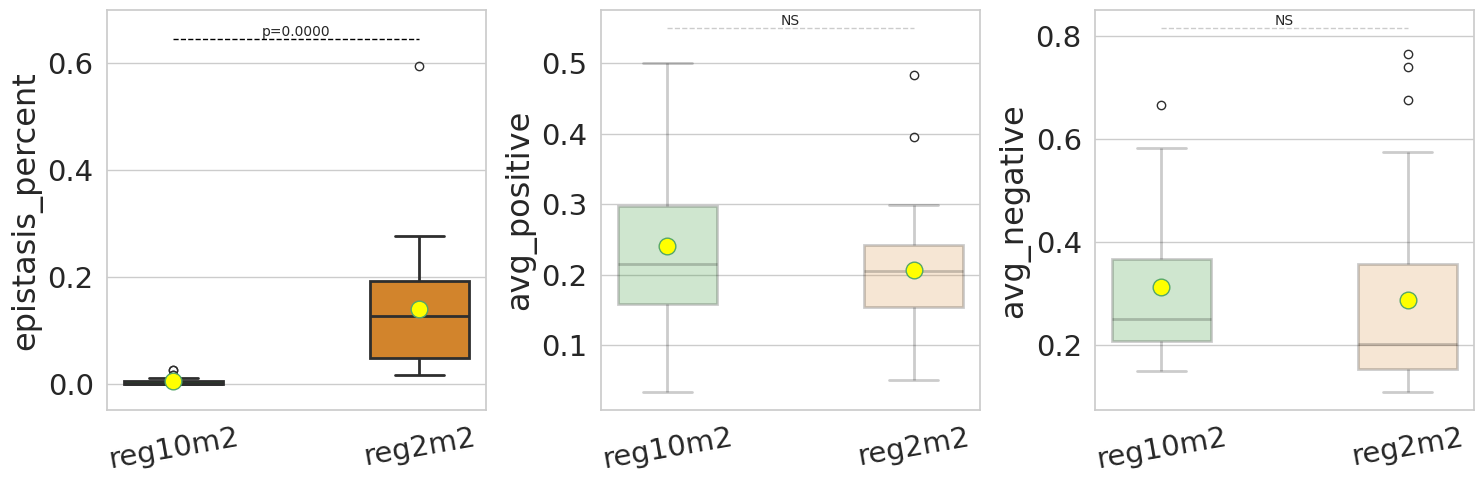

>> 100


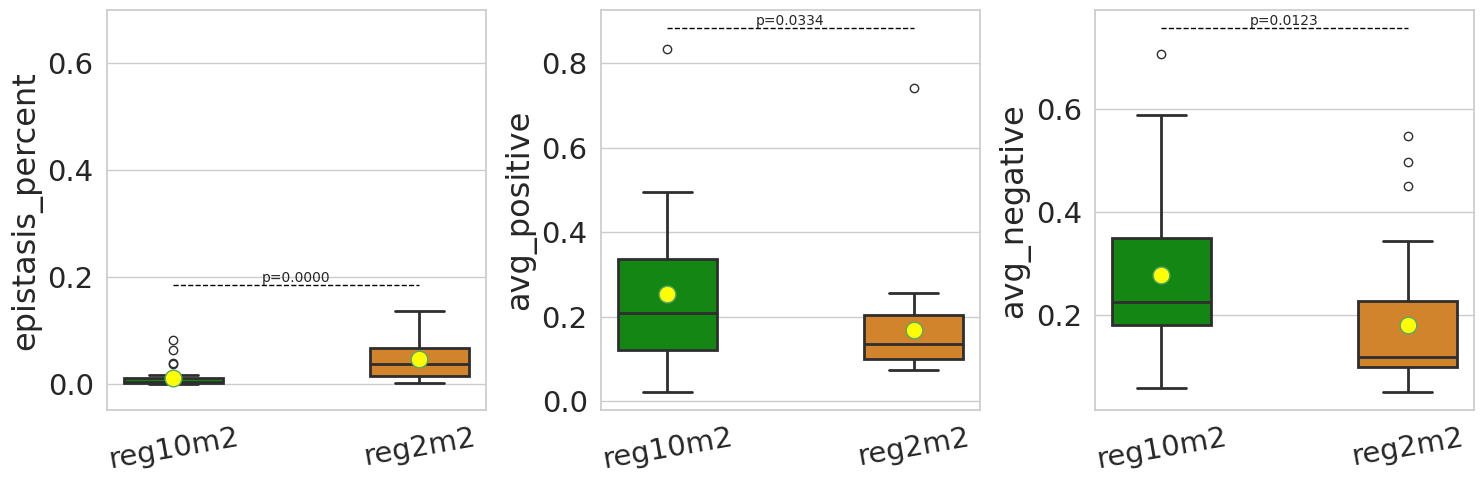

>>>>> coverage
>> 0


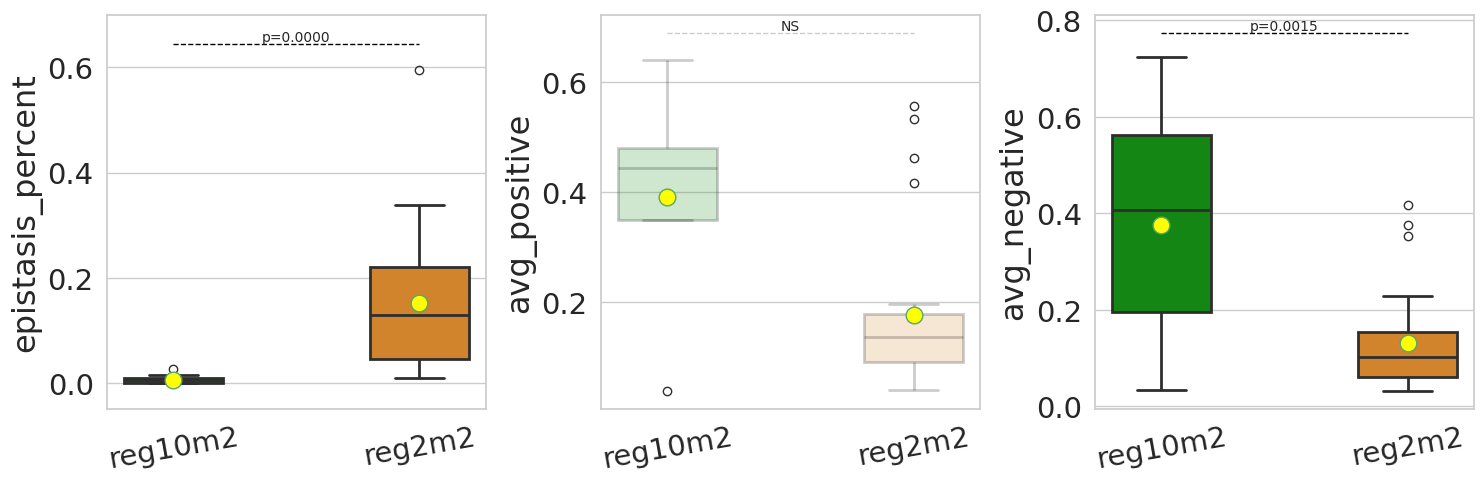

>> 100


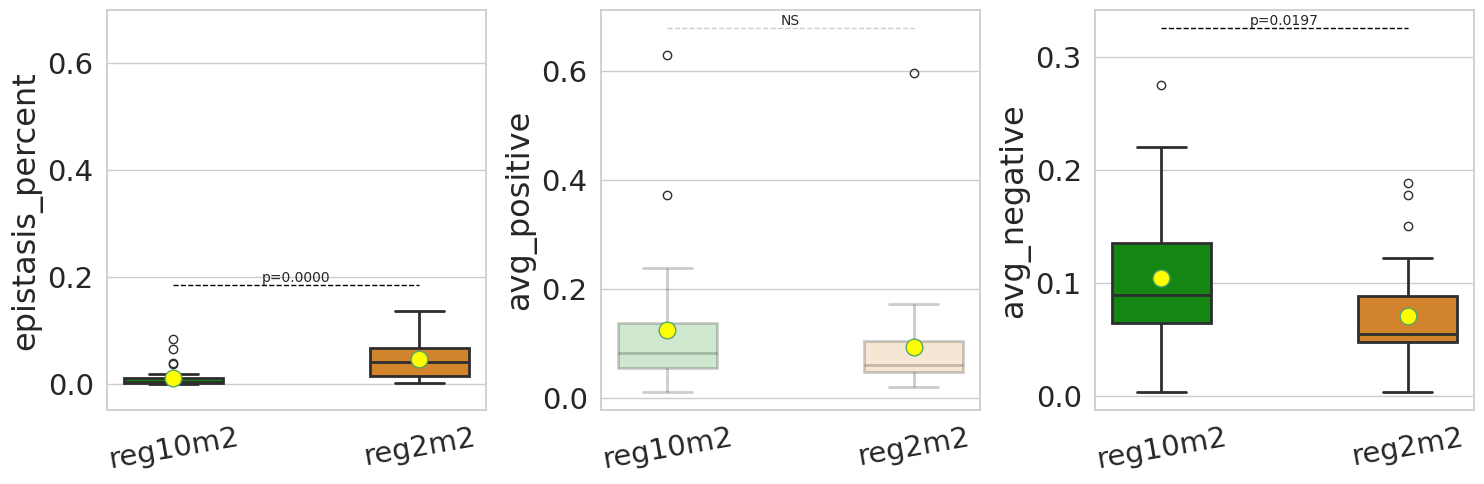

>>>>> extensiveness_prop
>> 0


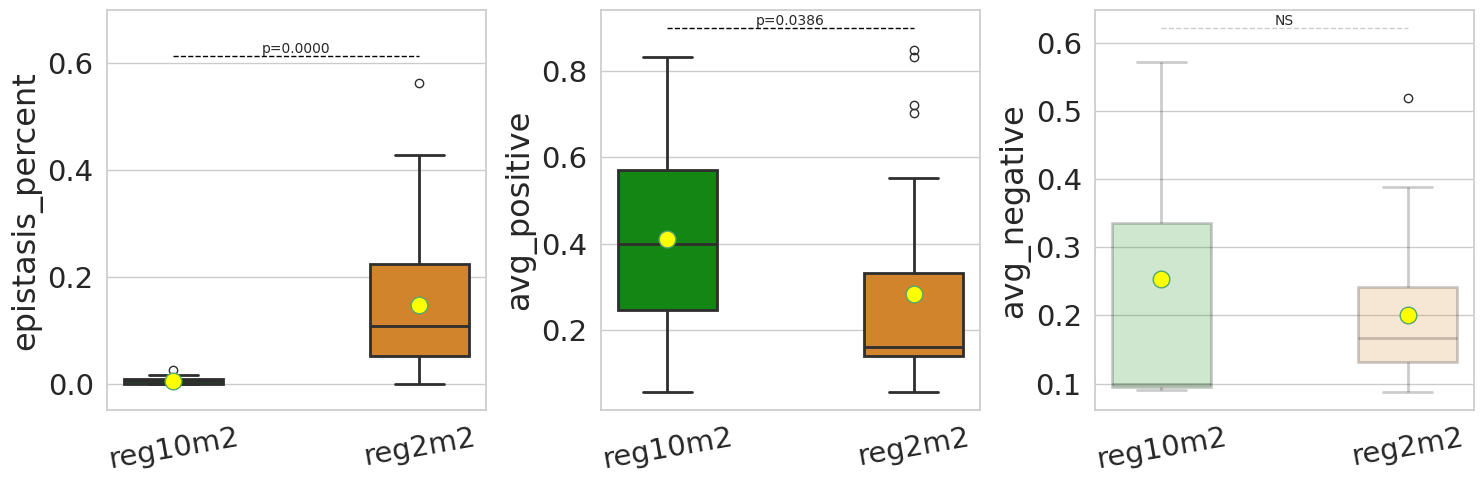

>> 100


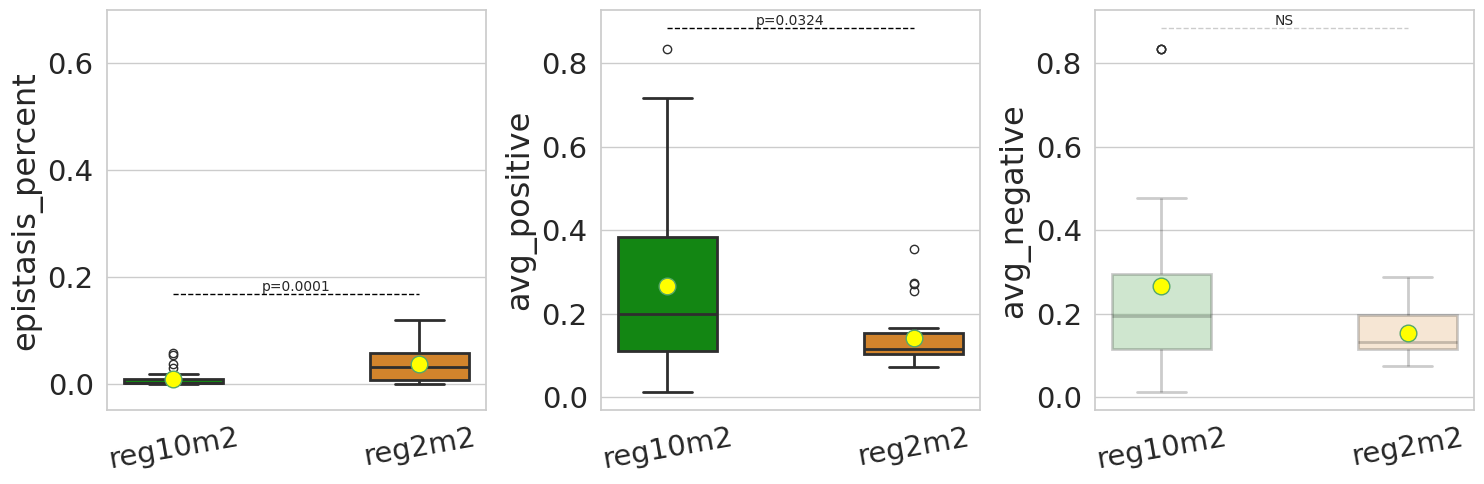

>>>>> branching_prop
>> 0


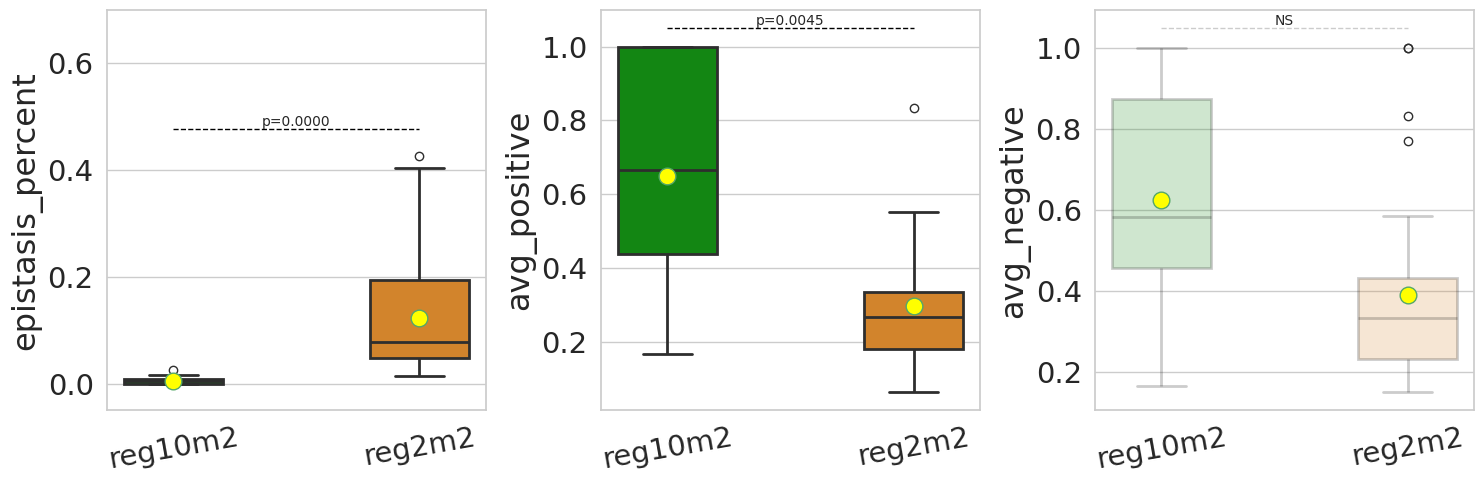

>> 100


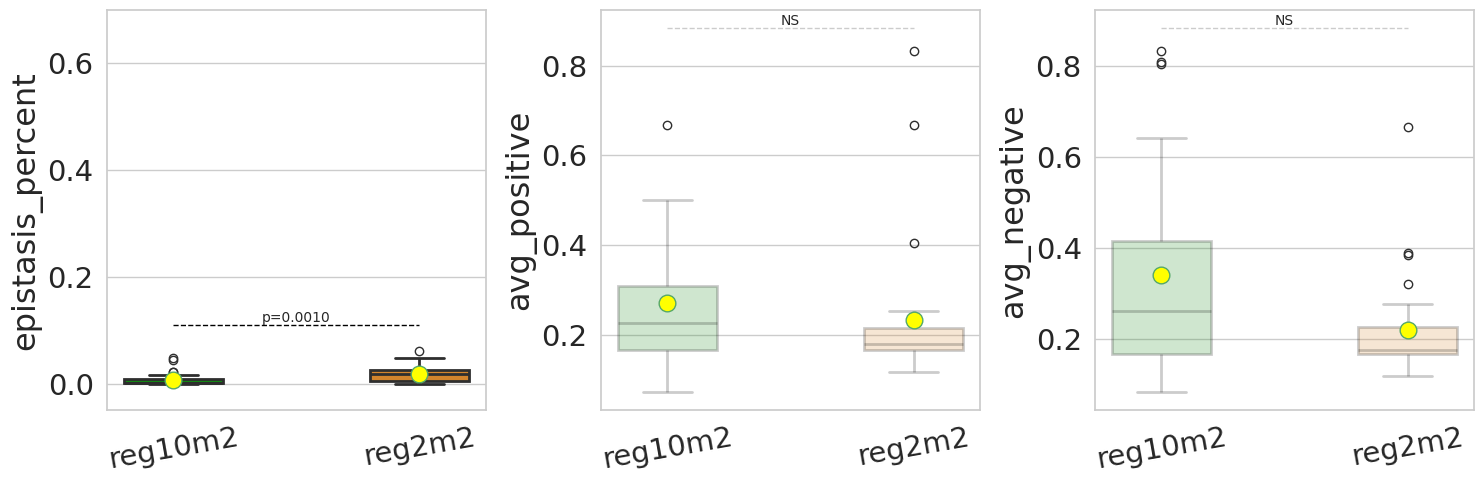

>>>>> modules_count
>> 0


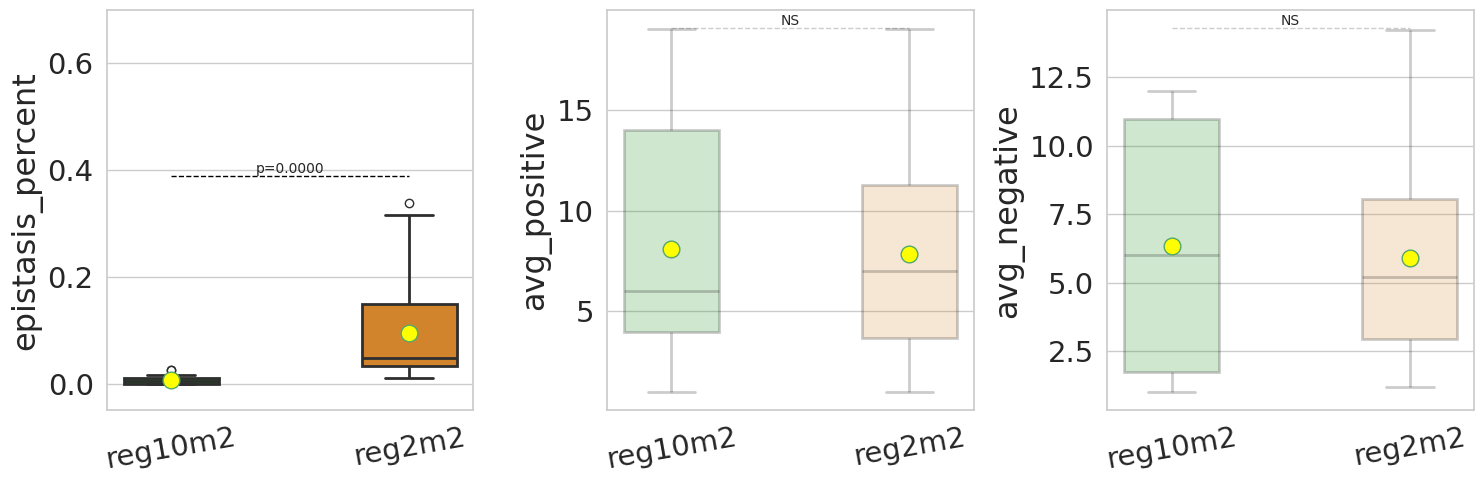

>> 100


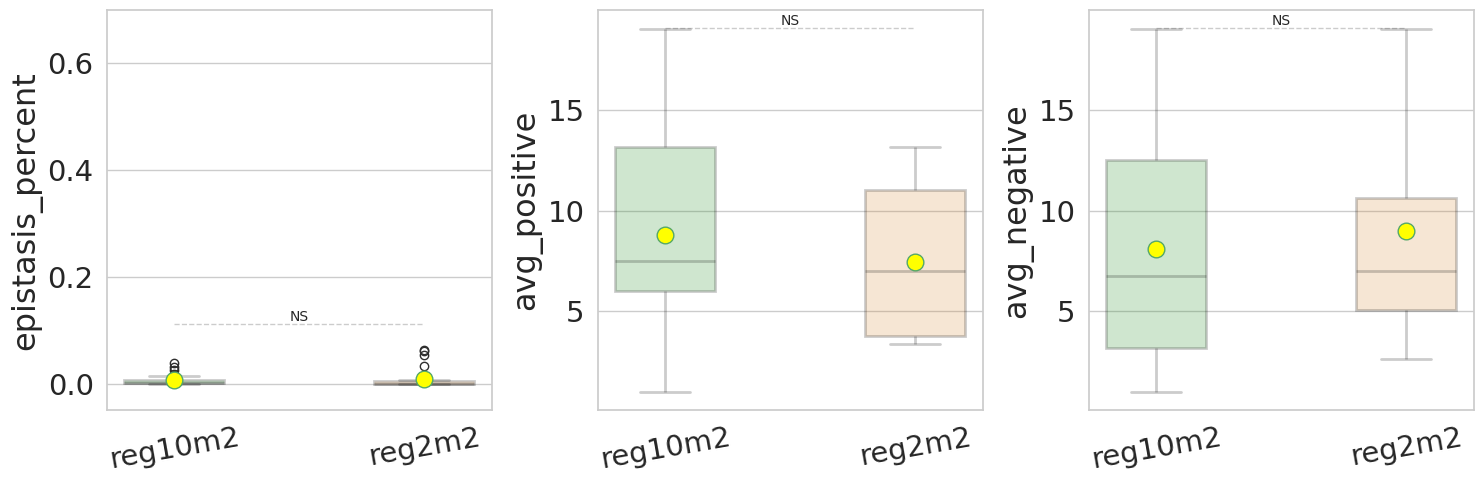

>>>>> hinge_prop
>> 0


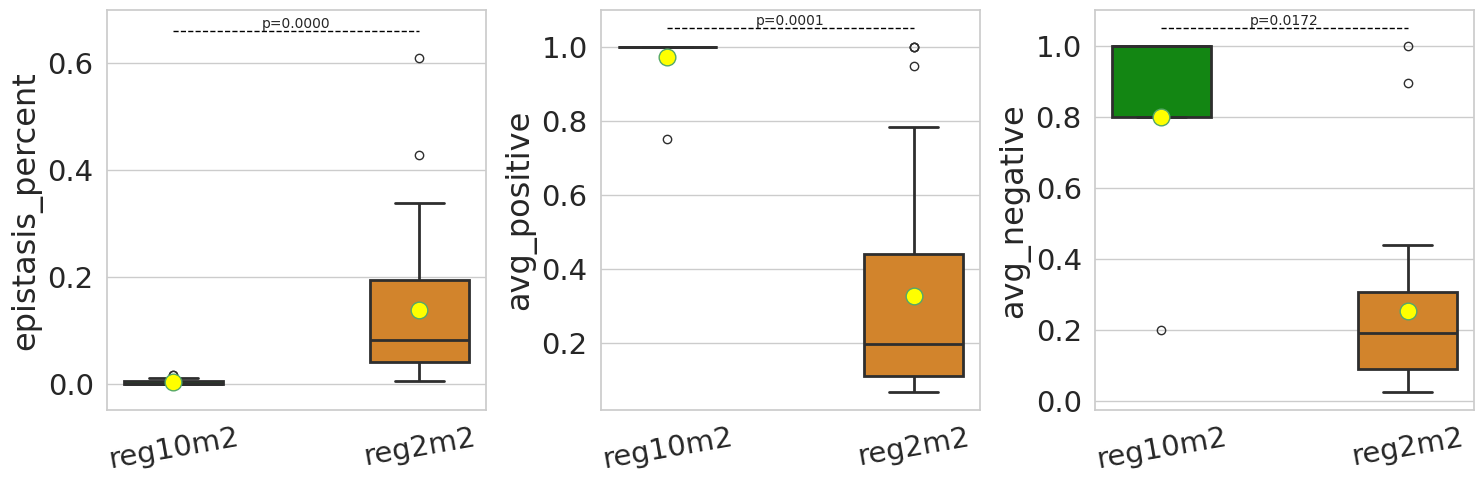

>> 100


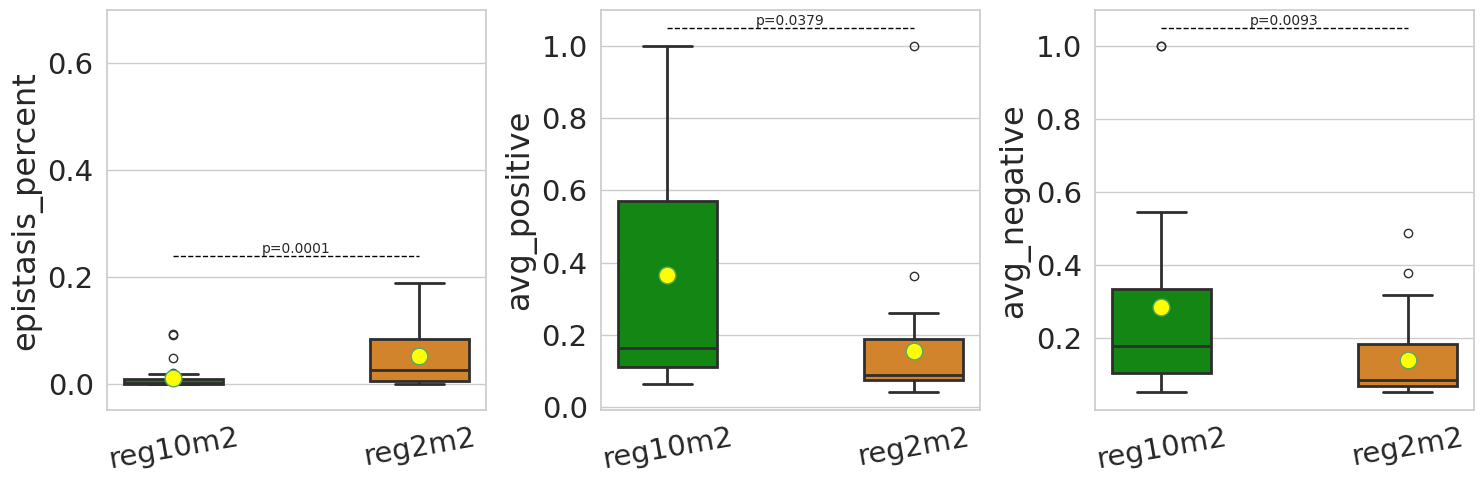

ok


In [47]:
### EPISTASIS CHANGES r10/r2: raw data ###

metrics = ['epistasis_percent',  'avg_positive',  'avg_negative']
metric_labels = ['epistasis %','strength +', 'strength -']
#epistasis strenght (+)
clrs = ['#009900',
        '#EE8610']

avg_pos_scale = {'disp_y': [-0.5, 4],'extremities_prop': [-0.05, 1.1],'symmetry': [-0.05, 1.15], 'distance': [-0.5, 25]}

for trait in traits:
    print('>>>>>',trait)
    df_trait = df_traits[trait].copy(deep=True)
    
    for gen in [0, 100]:
        print('>>',gen)
        df_trait_exp = df_trait[df_trait['gen'] == gen]
        df_trait_exp = df_trait_exp[ (df_trait_exp['ranking'] == 'best') ] 
        
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))  
        sb.set(rc={"axes.titlesize": 23, "axes.labelsize": 23, 'ytick.labelsize': 21, 'xtick.labelsize': 21})
        sb.set_style("whitegrid")
        
        for idx, metric in enumerate(metrics):
            ax = axes[idx]

            filtered_clean = df_trait_exp[pd.notna(df_trait_exp[metric])]
            ini_gen = filtered_clean[filtered_clean['experiment_name'] == 'reg10m2'][f'{metric}']
            end_gen = filtered_clean[filtered_clean['experiment_name'] == 'reg2m2'][f'{metric}']
     
            _, p_value = mannwhitneyu(ini_gen, end_gen, alternative='two-sided')
           # print(f"\nMetric: {metric}, p-value: {round(p_value, 4)}")

            sb.boxplot(x='experiment_name', y=f'{metric}', data=filtered_clean,
                       palette=clrs, width=0.4, showmeans=True, linewidth=2, fliersize=6,
                       meanprops={"marker": "o", "markerfacecolor": "yellow", "markersize": "12"}, ax=ax)

            y_max = filtered_clean[f'{metric}'].max() + 0.05  #
            x_positions = [0, 1]  
            ax.plot(x_positions, [y_max, y_max], color='black', linestyle='--', linewidth=1)
            if p_value >= 0.05:
                sig = 'NS'
                alpha = 0.2
                for patch in ax.patches:
                    patch.set_alpha(alpha)
                    patch.set_edgecolor((0.0, 0.0, 0.0, alpha))  # Example RGBA border color
                for line in ax.lines:
                    if line.get_linestyle() == '-' or line.get_linestyle() == '--':
                        line.set_color((0.0, 0.0, 0.0, alpha))  
                 
            else:
                sig = f'p={p_value:.4f}'
            ax.text(x=0.5, y=y_max, s=sig, ha='center', va='bottom', fontsize=10)
            
            if metric in ['epistasis_percent']:
                ax.set_ylim(-0.05, 0.7)

            if metric == 'avg_positive' or metric == 'avg_negative':
                if trait in avg_pos_scale.keys():
                    ax.set_ylim(avg_pos_scale[trait][0], avg_pos_scale[trait][1])
      
            ax.tick_params(axis='x', labelrotation=10)
            
            ax.set_xlabel('')
            ax.set_ylabel(f'{metric}')
       
        plt.tight_layout()
        plt.show()

print('ok')





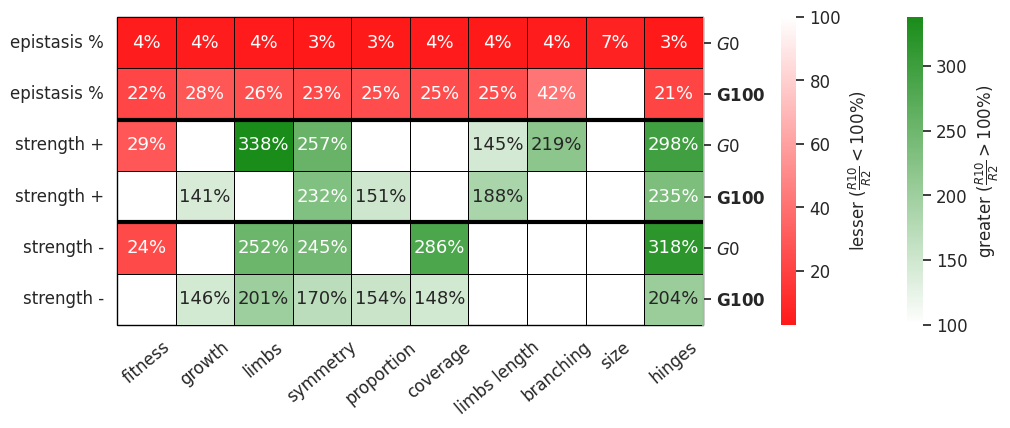

In [48]:
### EPISTASIS CHANGES r10/r2:  visualization ###

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap, Normalize
import matplotlib.patches as patches

# Define traits and metrics

generations = [0, 100]

# Store ratio values for each metric, trait, and generation
heatmap_data = np.zeros((len(metrics) * len(generations), len(traits)))
heatmap_p = np.zeros((len(metrics) * len(generations), len(traits)))
annot_data = np.empty((len(metrics) * len(generations), len(traits)), dtype=object)

row_labels = []
gen_labels = []

for i, metric in enumerate(metrics):
    for gen_idx, gen in enumerate(generations):
        row_index = i * len(generations) + gen_idx
        row_labels.append(f"{metric}")
        if gen == 100:
            gen_labels.append(rf'$\mathbf{{G{gen}}}$')
        else:
            gen_labels.append(rf'$\mathit{{G{gen}}}$')
            
        for j, trait in enumerate(traits):
            df_trait = df_traits[trait].copy(deep=True)
            df_trait_exp = df_trait[df_trait['gen'] == gen]
            df_trait_exp = df_trait_exp[df_trait_exp['ranking'] == 'best']

            filtered_clean = df_trait_exp[pd.notna(df_trait_exp[metric])]
            exp1 = filtered_clean[filtered_clean['experiment_name'] == 'reg2m2'][metric]
            exp2 = filtered_clean[filtered_clean['experiment_name'] == 'reg10m2'][metric]

            # Calculate averages and ratio
            avg_exp1 = exp1.mean()
            avg_exp2 = exp2.mean()
            ratio = (avg_exp2 / avg_exp1) * 100

             # Perform the Mann-Whitney U test
            _, p_value = mannwhitneyu(exp1, exp2, alternative='two-sided')

            # Assuming heatmap_data is your data matrix and annot_data are the annotations.
            mask = heatmap_p > 0.05 # Create a mask where the value is..
            
            # Store in heatmap data
            heatmap_data[row_index, j] = ratio
            heatmap_p[row_index, j] = p_value
            annot_data[row_index, j] =  f"{ratio:.0f}%"

# Create custom colormaps
# Green for values > 100 (light to dark green)
green_cmap = LinearSegmentedColormap.from_list("green", ["white", "green"])
# Red for values < 100 (inverted: dark to light red)
red_cmap = LinearSegmentedColormap.from_list("red", ["red", "white"])

# Normalize for both colorbars
norm_green = Normalize(vmin=100, vmax=338)  # For the green range, from 100 to >100
norm_red = Normalize(vmin=3, vmax=100)     # For the red range, from 100 back to 0 (inverted)

# Create masks
mask_pvalue = heatmap_p > 0.05  # Mask for p-values > 0.05
mask_green = heatmap_data > 100  # Mask for values greater than 100 (green)
mask_red = heatmap_data < 100   # Mask for values less than 100 (red)

# Combine the masks for each condition
mask_combined_green = mask_pvalue | ~mask_green  # Cells that should be masked in green colormap
mask_combined_red = mask_pvalue | ~mask_red      # Cells that should be masked in red colormap

fig, ax = plt.subplots(figsize=(12, 4))

# Plot heatmap for values > 100 with green colormap and black cell borders
sns.heatmap(
    heatmap_data, annot=annot_data, fmt="",
    cmap=green_cmap, linewidths=0.5, linecolor='black',
    alpha=0.9, annot_kws={'size': 13},
    xticklabels=traits, yticklabels=row_labels,
    ax=ax, mask=mask_combined_green, norm=norm_green,
    cbar_kws={'label': r'greater $(\frac{R10}{R2} >100\%)$', 'pad': 0.01}
)

# Plot heatmap for values < 100 with red colormap and black cell borders
sns.heatmap(
    heatmap_data, annot=annot_data, fmt="",
    cmap=red_cmap, linewidths=0.5, linecolor='black',
    alpha=0.9, annot_kws={'size': 13},
    xticklabels=traits, yticklabels=row_labels,
    ax=ax, mask=mask_combined_red, norm=norm_red,
    cbar_kws={'label': r'lesser $(\frac{R10}{R2} <100\%)$', 'pad': 0.10}
)

# Overlay crosshatching for non-significant p-values (p > 0.05)
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        if mask_pvalue[i, j]:
            rect = patches.Rectangle(
                (j, i), 1, 1, linewidth=0, edgecolor='none',
                facecolor='none', hatch='\\', alpha=0.5
            )
            ax.add_patch(rect)

# Remove grid lines
ax.set_xticks(ax.get_xticks(), minor=True)
ax.grid(False)

# Set x tick labels to font size 12
ax.set_xticklabels(traits_labels, rotation=40, fontsize=12)

# Adjust y-axis labels: primary labels (e.g., metric) on the left...
ax.set_yticklabels(np.repeat(metric_labels, 2), rotation=0, ha='right', fontsize=12)
# ...and a secondary y-axis for the generation labels on the right
ax2 = ax.secondary_yaxis('right')
ax2.set_yticks(ax.get_yticks())
ax2.set_yticklabels(gen_labels, rotation=0, ha='left', fontsize=12)

# Adjust color bar tick and label sizes for both color bars
cbar_green = ax.collections[0].colorbar
cbar_green.ax.tick_params(labelsize=12)
cbar_green.ax.yaxis.label.set_size(12)

cbar_red = ax.collections[-1].colorbar
cbar_red.ax.tick_params(labelsize=12)
cbar_red.ax.yaxis.label.set_size(12)

ax.patch.set_edgecolor('black')
ax.patch.set_linewidth(1)

# After plotting the heatmap
ax.axhline(y=2, color='black', linewidth=3)
ax.axhline(y=4, color='black', linewidth=3)

#plt.xlabel("Traits")
#plt.ylabel("Metrics")
#plt.title("Epistasis Changes")

fig.savefig(f'{path}/knockouts/epistasis_change_R10R2.png', dpi=300, bbox_inches='tight')



>>>>> disp_y
>> reg10m2


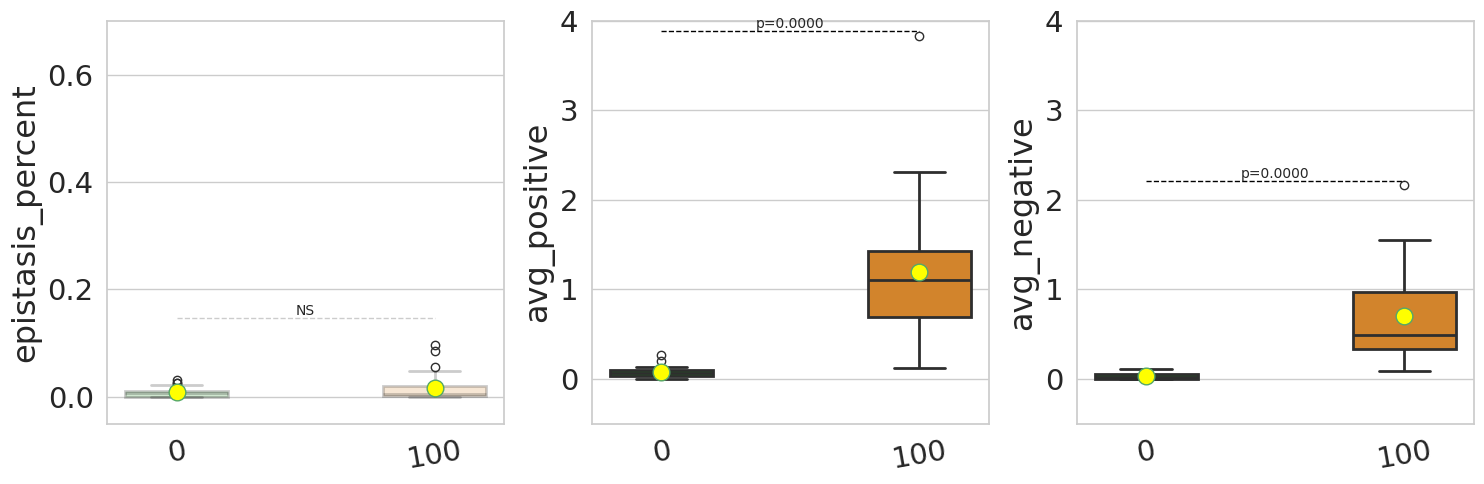

>> reg2m2


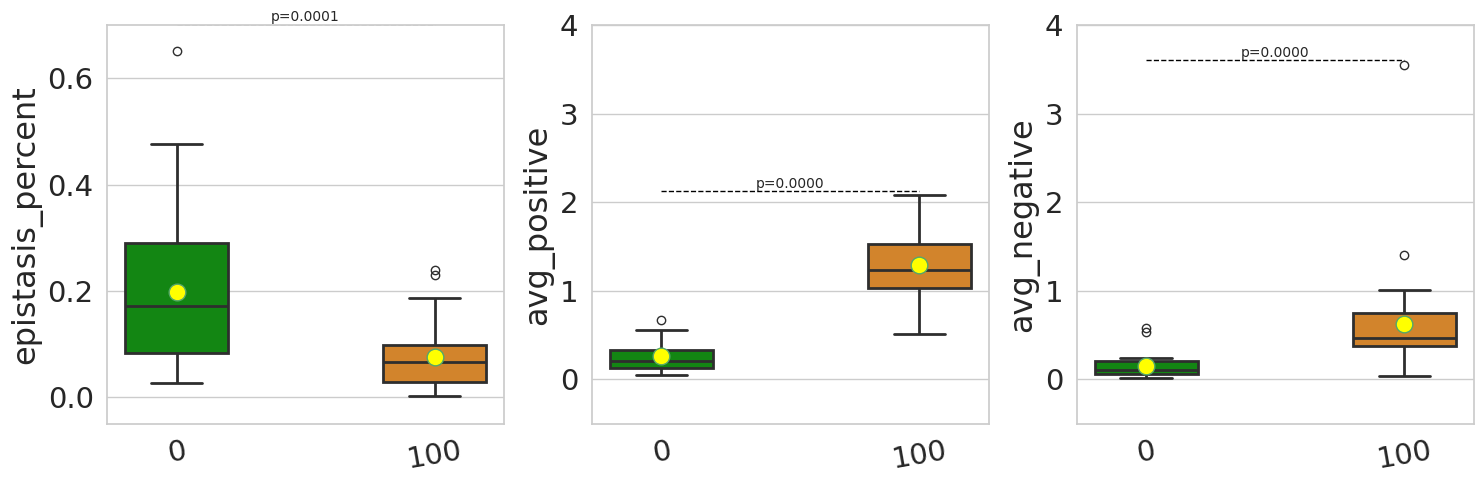

>>>>> distance
>> reg10m2


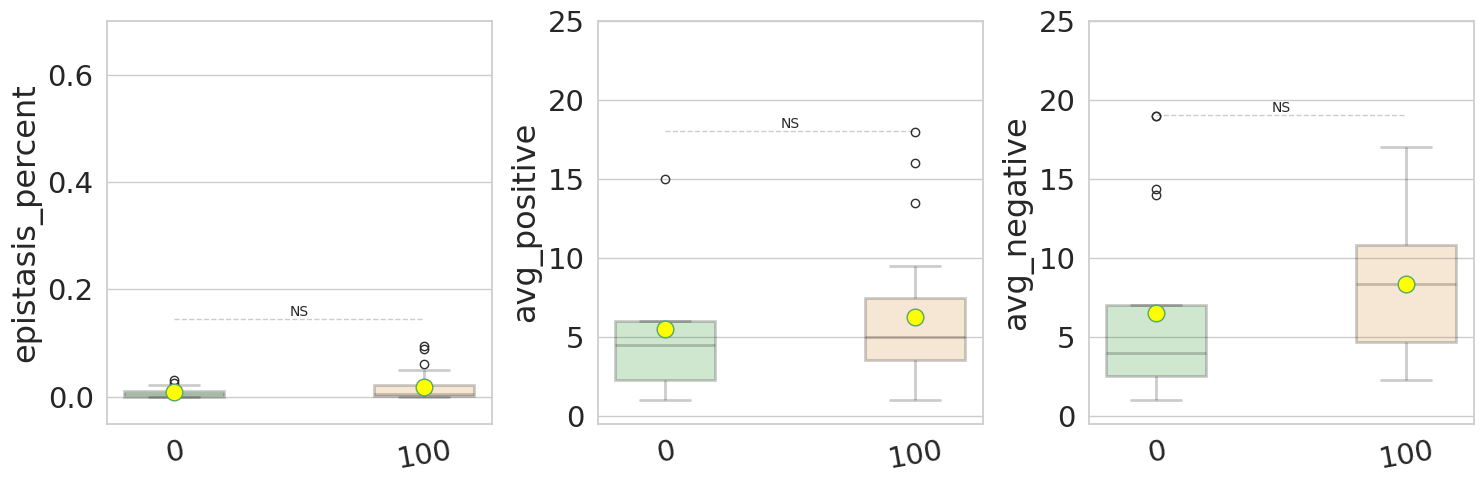

>> reg2m2


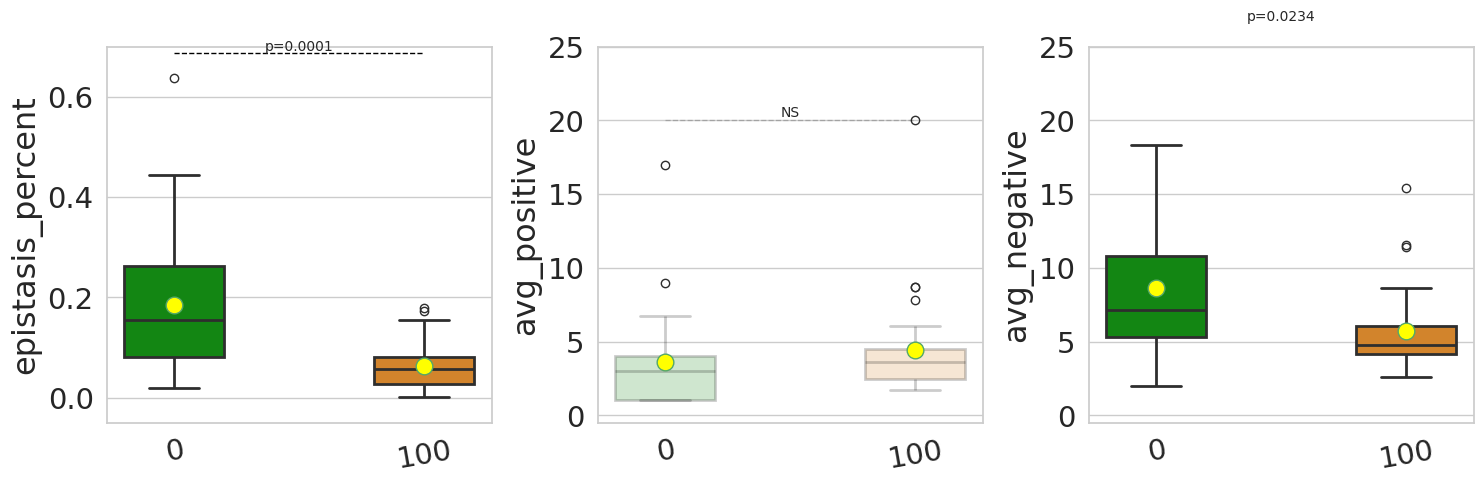

>>>>> extremities_prop
>> reg10m2


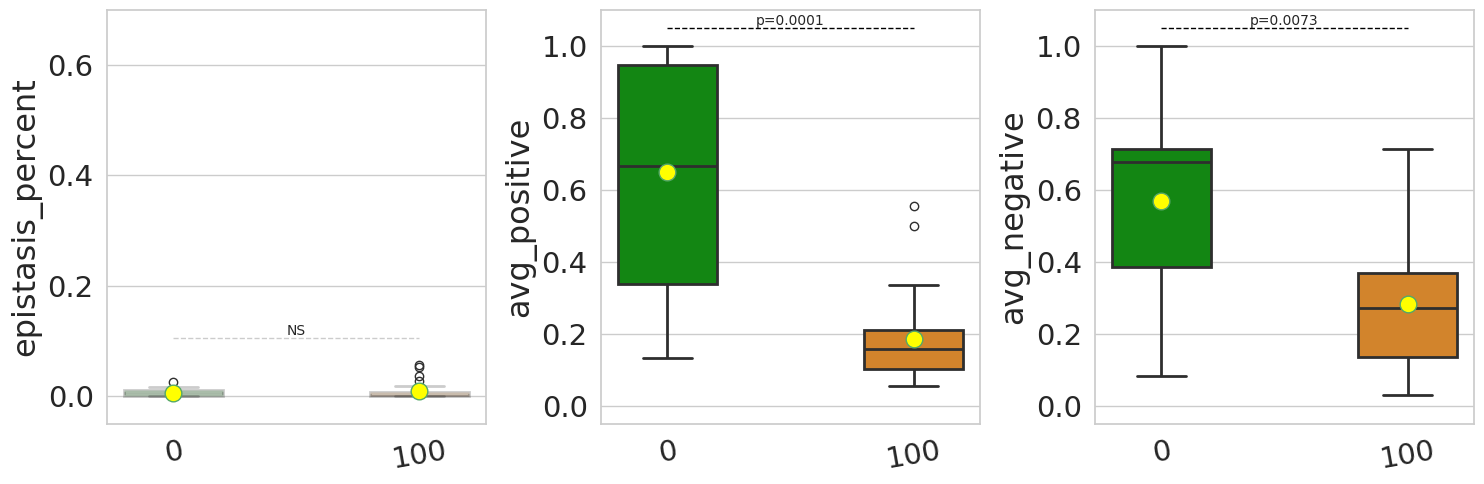

>> reg2m2


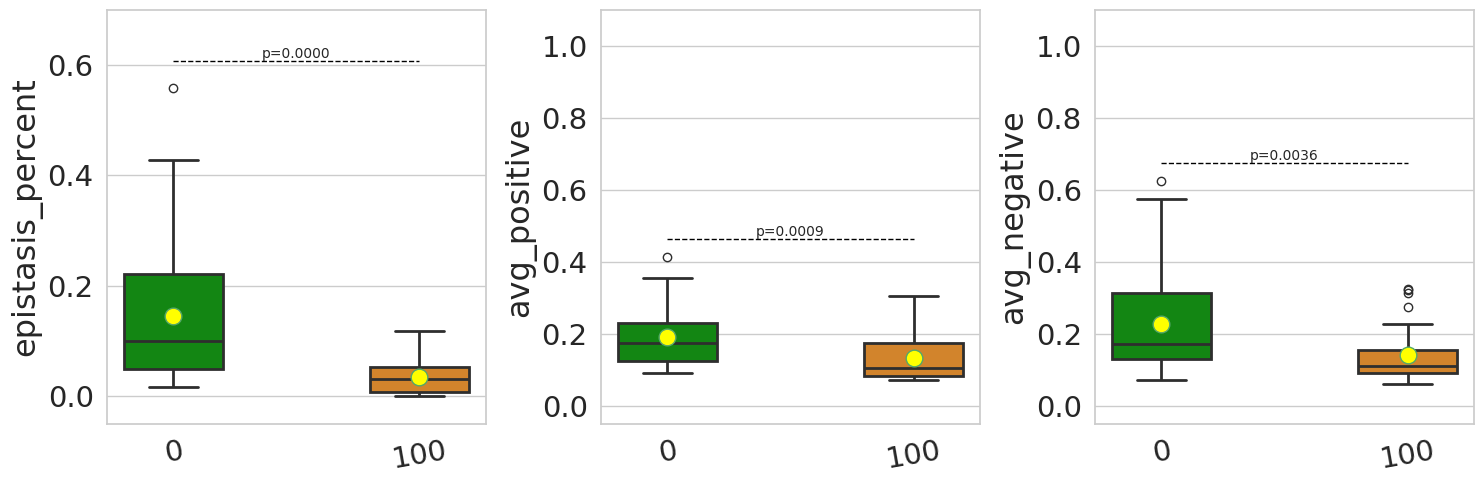

>>>>> symmetry
>> reg10m2


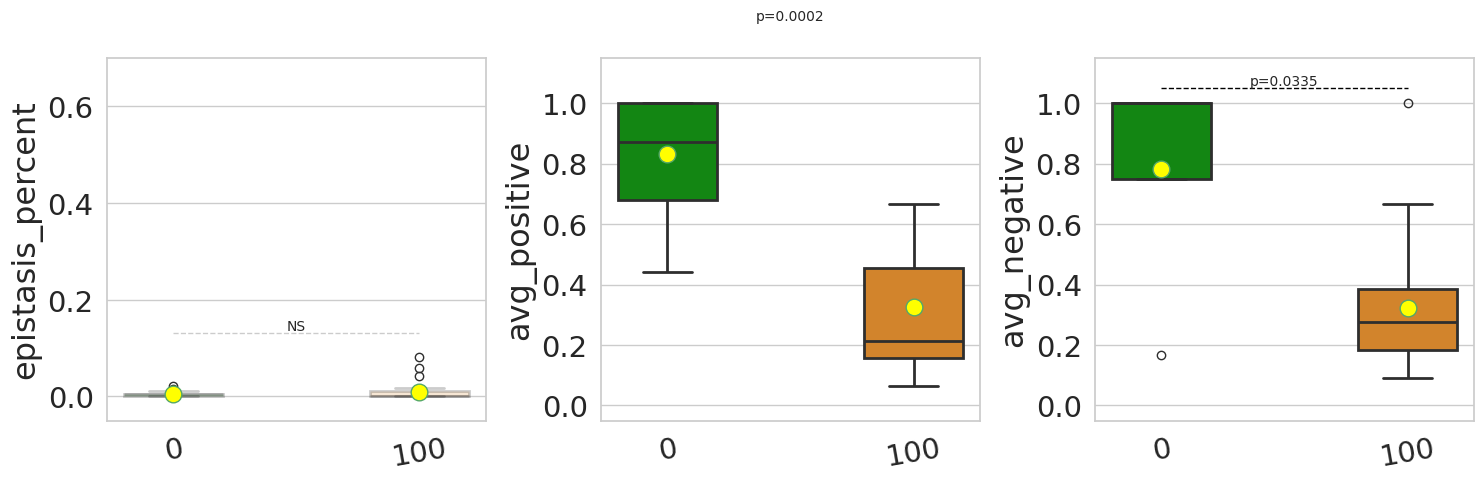

>> reg2m2


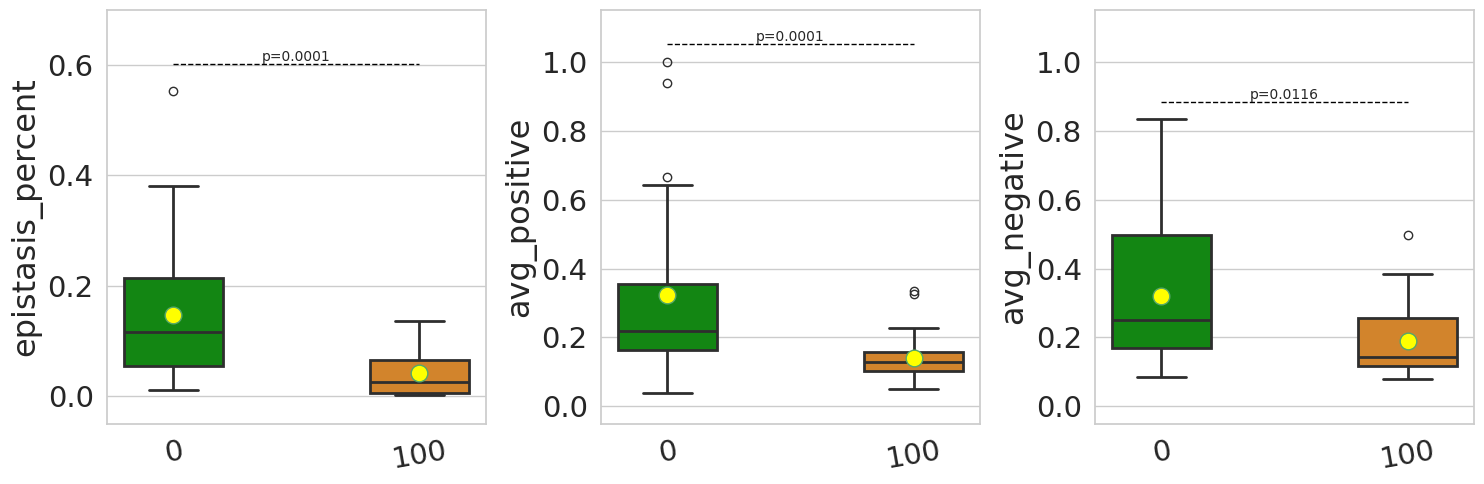

>>>>> proportion
>> reg10m2


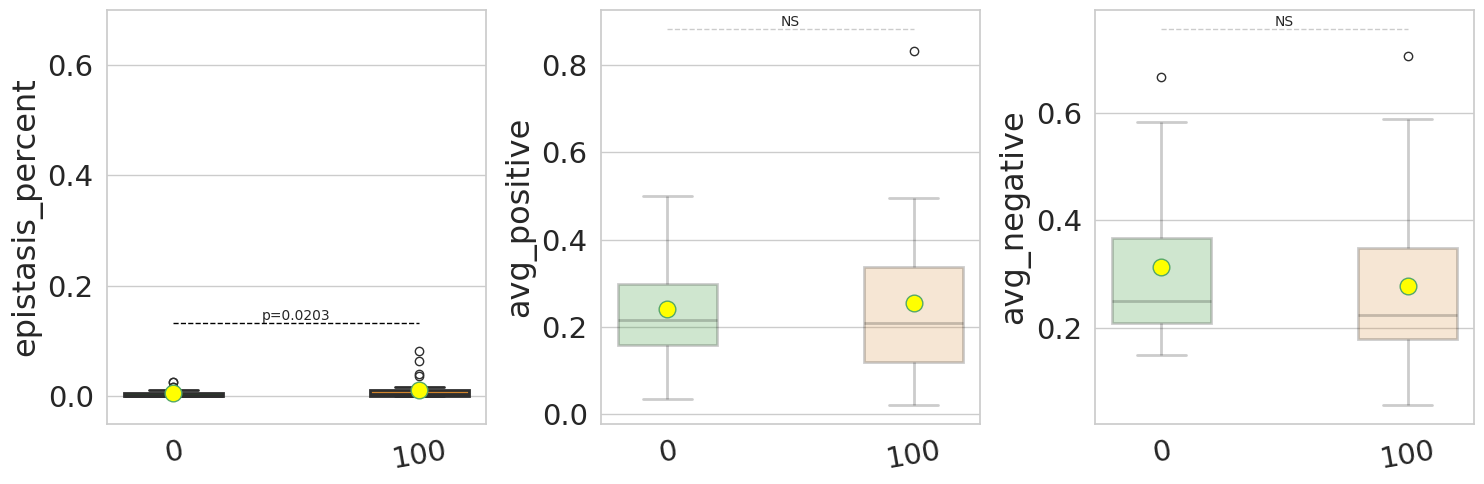

>> reg2m2


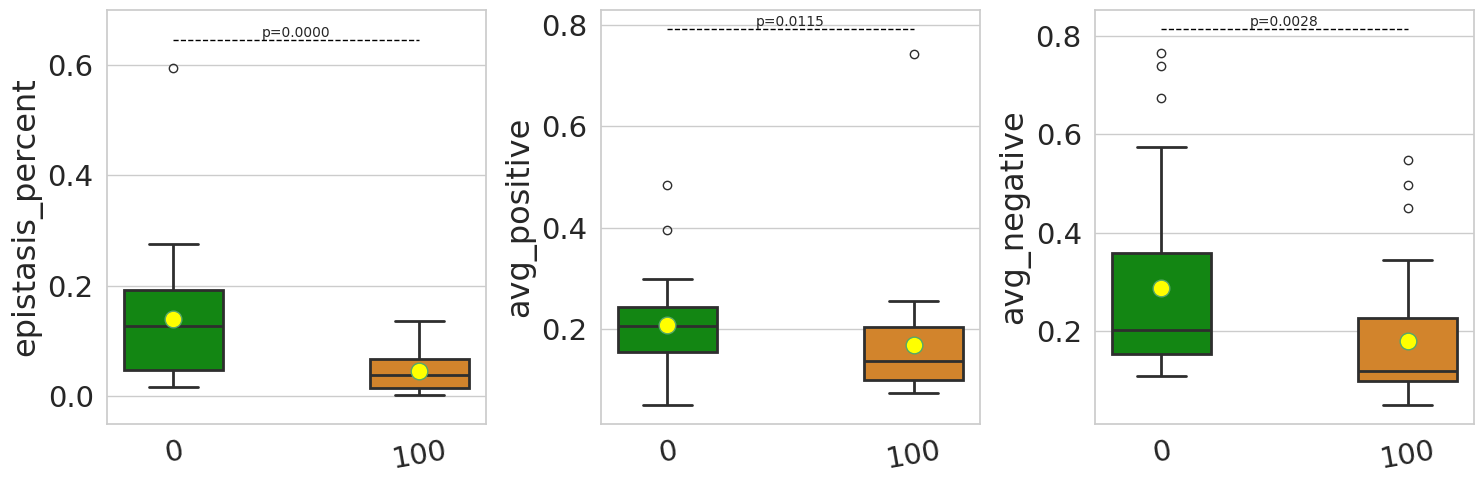

>>>>> coverage
>> reg10m2


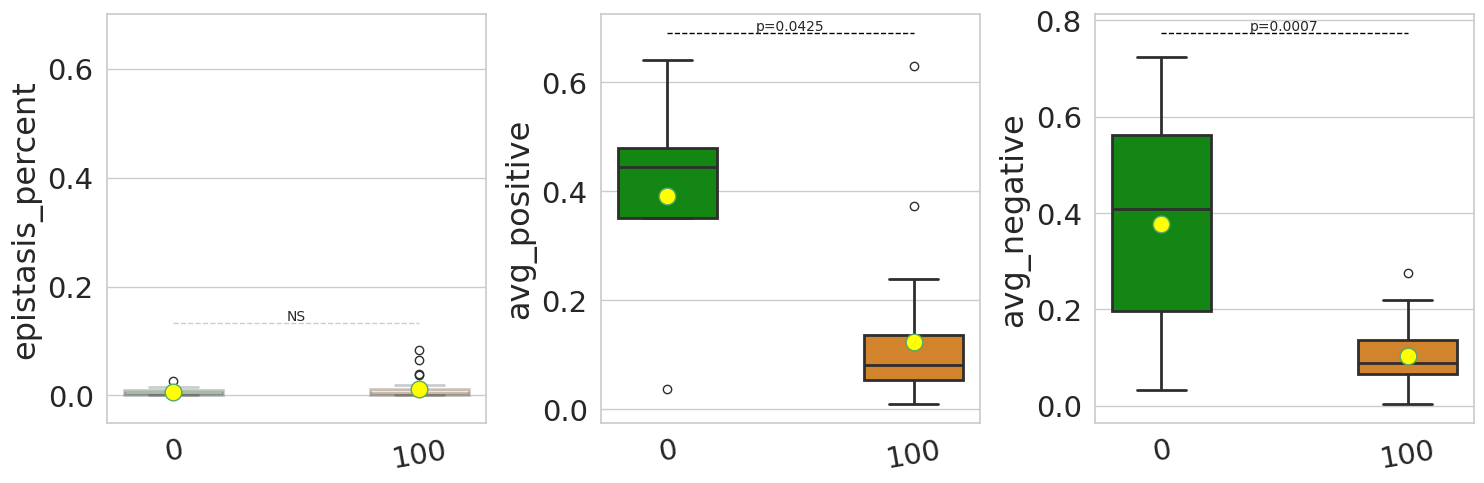

>> reg2m2


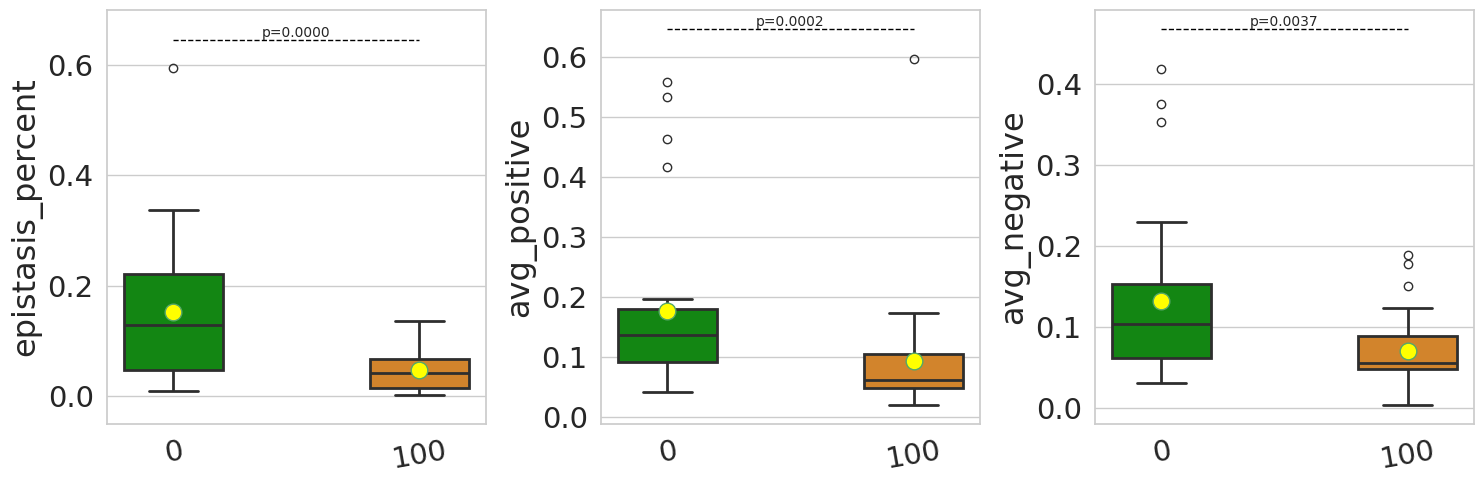

>>>>> extensiveness_prop
>> reg10m2


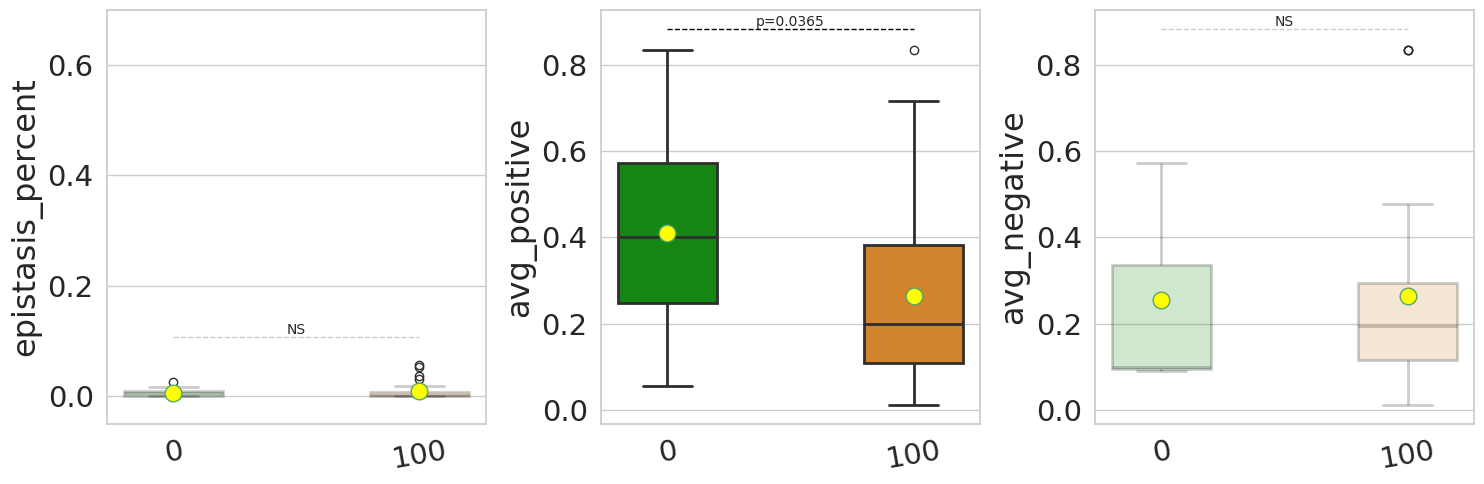

>> reg2m2


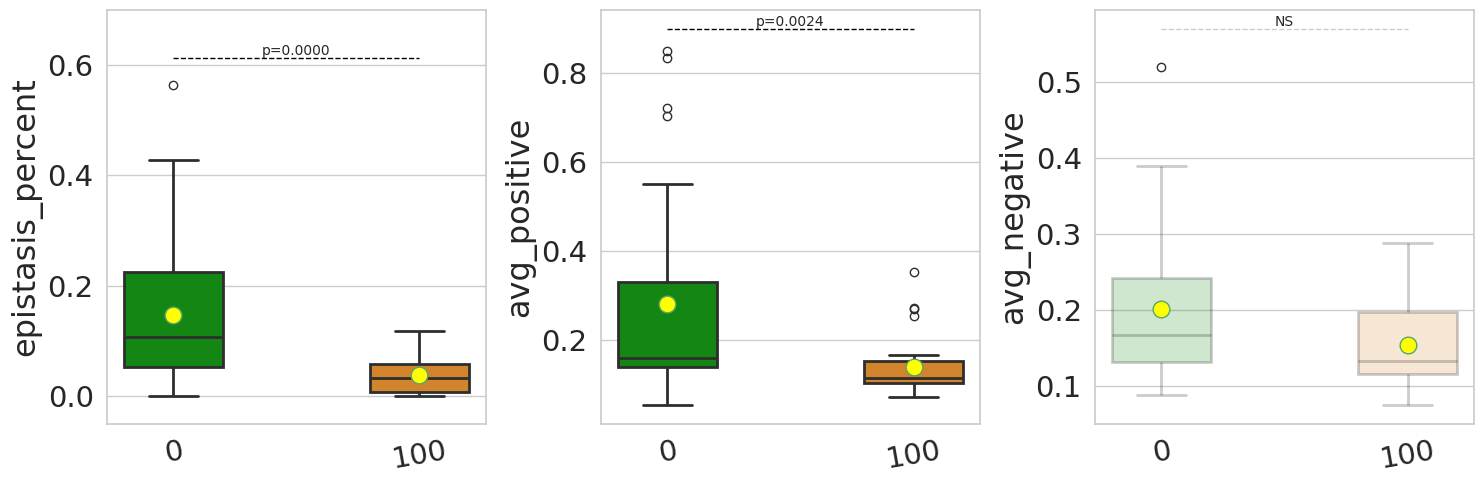

>>>>> branching_prop
>> reg10m2


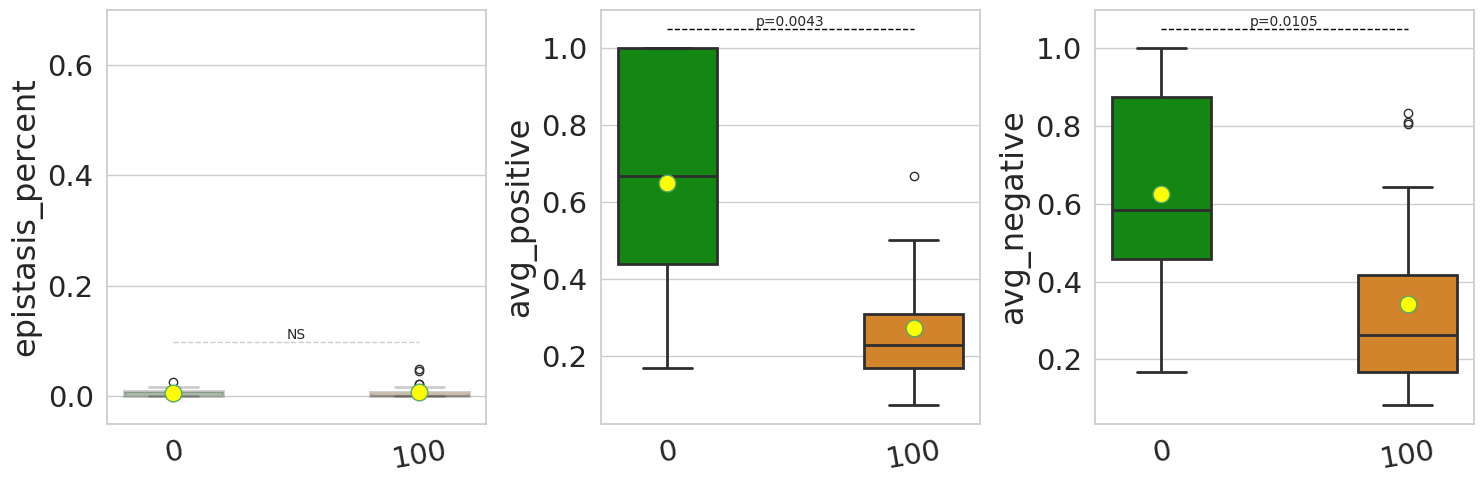

>> reg2m2


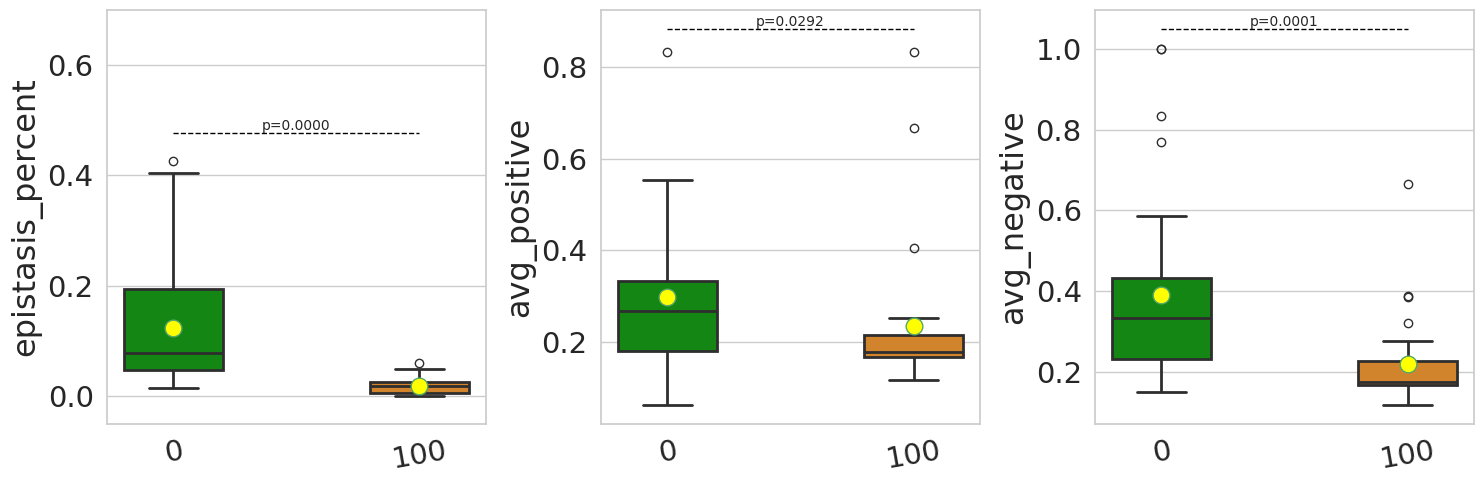

>>>>> modules_count
>> reg10m2


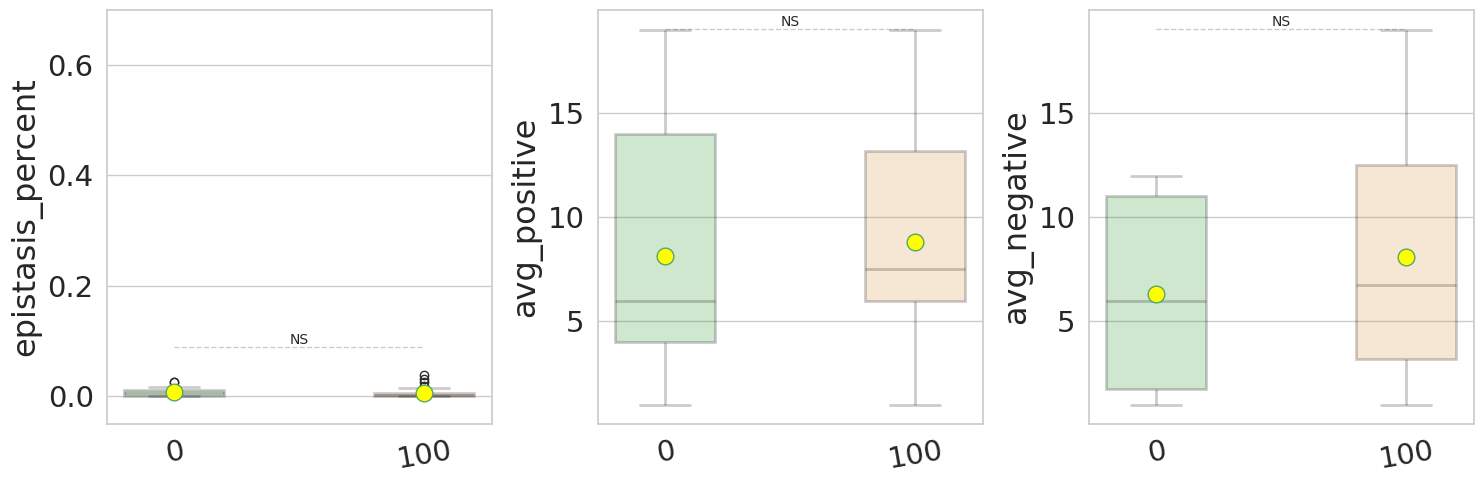

>> reg2m2


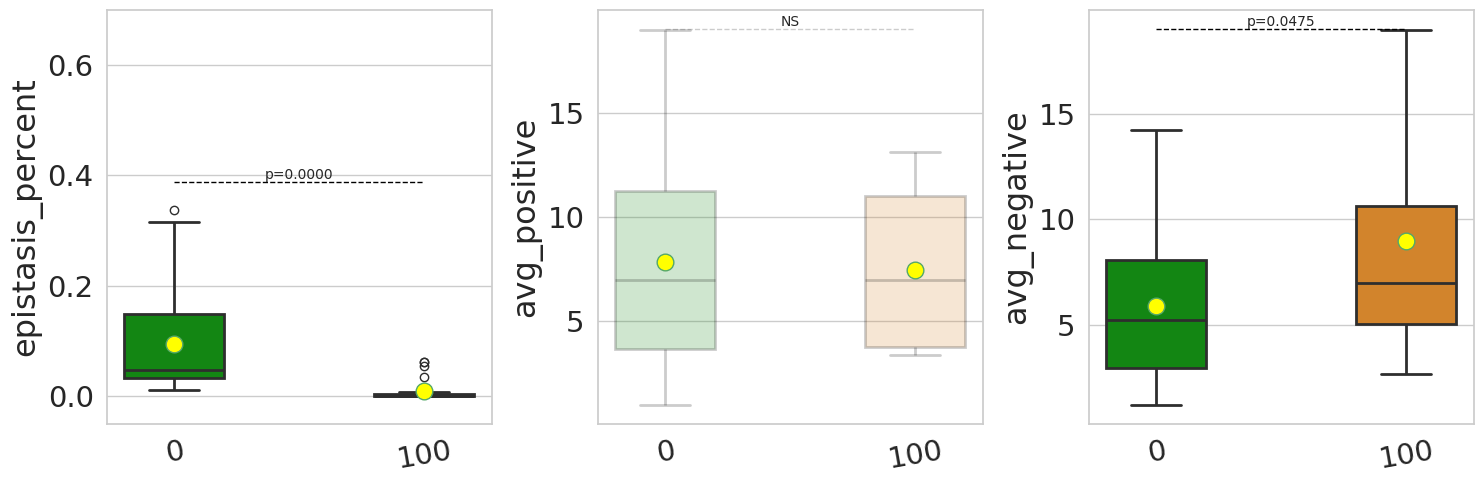

>>>>> hinge_prop
>> reg10m2


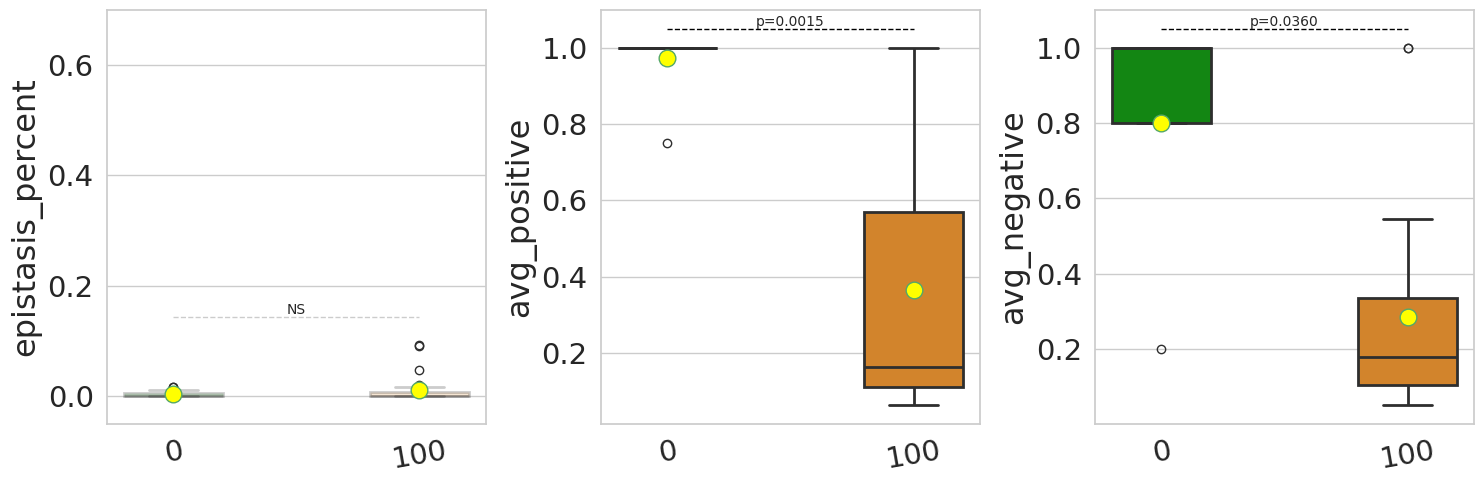

>> reg2m2


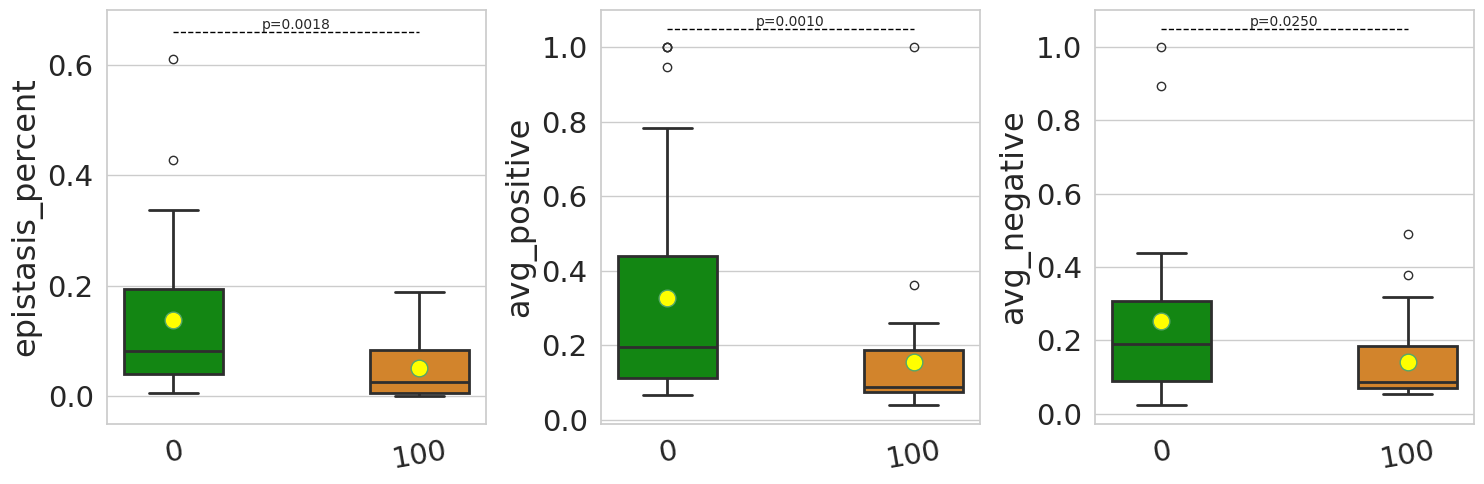

In [49]:


### EPISTASIS CHANGES g1/g100: raw data ###

clrs = ['#009900',
        '#EE8610']

avg_pos_scale = {'disp_y': [-0.5, 4],'extremities_prop': [-0.05, 1.1],'symmetry': [-0.05, 1.15], 'distance': [-0.5, 25]}

for trait in traits:
    print('>>>>>',trait)
    df_trait = df_traits[trait].copy(deep=True)
    

    for exp in experiments:
        print('>>',exp)
        df_trait_exp = df_trait[df_trait['experiment_name'] == exp]
        df_trait_exp = df_trait_exp[ (df_trait_exp['ranking'] == 'best') ] 
        
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))  
        sb.set(rc={"axes.titlesize": 23, "axes.labelsize": 23, 'ytick.labelsize': 21, 'xtick.labelsize': 21})
        sb.set_style("whitegrid")
        
        for idx, metric in enumerate(metrics):
            ax = axes[idx]

            filtered_clean = df_trait_exp[pd.notna(df_trait_exp[metric])]
            ini_gen = filtered_clean[filtered_clean['gen'] == 0][f'{metric}']
            end_gen = filtered_clean[filtered_clean['gen'] == 100][f'{metric}']

            _, p_value = mannwhitneyu(ini_gen, end_gen, alternative='two-sided')
           # print(f"\nMetric: {metric}, p-value: {round(p_value, 4)}")

            sb.boxplot(x='gen', y=f'{metric}', data=filtered_clean,
                       palette=clrs, width=0.4, showmeans=True, linewidth=2, fliersize=6,
                       meanprops={"marker": "o", "markerfacecolor": "yellow", "markersize": "12"}, ax=ax)

            y_max = filtered_clean[f'{metric}'].max() + 0.05  #
            x_positions = [0, 1]  
            ax.plot(x_positions, [y_max, y_max], color='black', linestyle='--', linewidth=1)
            if p_value >= 0.05:
                sig = 'NS'
                alpha = 0.2
                for patch in ax.patches:
                    patch.set_alpha(alpha)
                    patch.set_edgecolor((0.0, 0.0, 0.0, alpha))  # Example RGBA border color
                for line in ax.lines:
                    if line.get_linestyle() == '-' or line.get_linestyle() == '--':
                        line.set_color((0.0, 0.0, 0.0, alpha))  
                 
            else:
                sig = f'p={p_value:.4f}'
            ax.text(x=0.5, y=y_max, s=sig, ha='center', va='bottom', fontsize=10)
            
            if metric in ['epistasis_percent']:
                ax.set_ylim(-0.05, 0.7)

            if metric == 'avg_positive' or metric == 'avg_negative':
                if trait in avg_pos_scale.keys():
                    ax.set_ylim(avg_pos_scale[trait][0], avg_pos_scale[trait][1])
      
            ax.tick_params(axis='x', labelrotation=10)
            
            ax.set_xlabel('')
            ax.set_ylabel(f'{metric}')
       
        plt.tight_layout()
        plt.show()







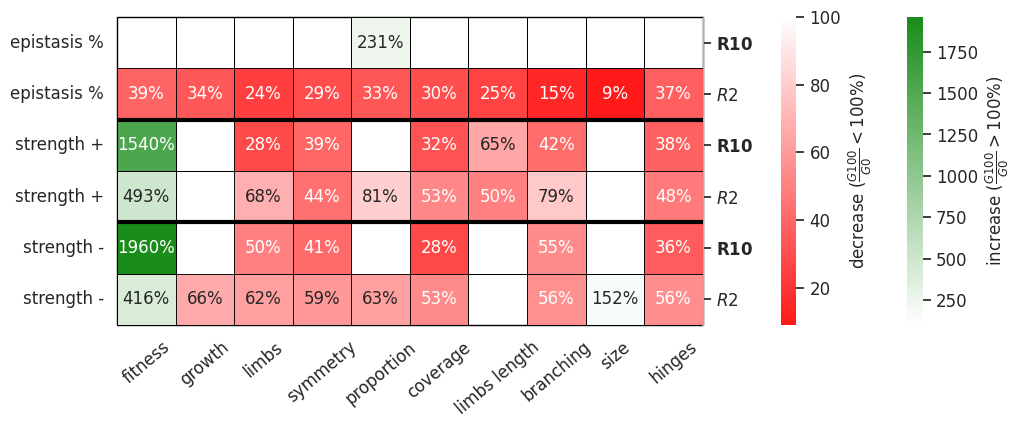

In [50]:

### EPISTASIS CHANGES g1/g100: vizualization ###

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap, Normalize
import matplotlib.patches as patches

generations = [0, 100]

# Store ratio values for each metric, trait, and generation
heatmap_data = np.zeros((len(metrics) * len(experiments), len(traits)))
heatmap_p = np.zeros((len(metrics) * len(experiments), len(traits)))
annot_data = np.empty((len(metrics) * len(experiments), len(traits)), dtype=object)

row_labels = []
exp_labels_local = []

for i, metric in enumerate(metrics):
    for exp_idx, exp in enumerate(experiments):
        row_index = i * len(experiments) + exp_idx
        row_labels.append(f"{metric}")
        
        if exp == 'reg10m2':
            exp_labels_local.append(rf'$\mathbf{{{exp_labels[exp_idx]}}}$')
        else:
            exp_labels_local.append(rf'$\mathit{{{exp_labels[exp_idx]}}}$')
        
        for j, trait in enumerate(traits):
            df_trait = df_traits[trait].copy(deep=True)
            df_trait_exp = df_trait[df_trait['experiment_name'] == exp]
            df_trait_exp = df_trait_exp[df_trait_exp['ranking'] == 'best']

            filtered_clean = df_trait_exp[pd.notna(df_trait_exp[metric])]
            ini_gen = filtered_clean[filtered_clean['gen'] == 0][f'{metric}']
            end_gen = filtered_clean[filtered_clean['gen'] == 100][f'{metric}']

            # Calculate the averages
            avg_ini_gen = ini_gen.mean()
            avg_end_gen = end_gen.mean()

            # Perform the Mann-Whitney U test
            _, p_value = mannwhitneyu(ini_gen, end_gen, alternative='two-sided')

            # Calculate the ratio of gen 100 by gen 0
            ratio = (avg_end_gen / avg_ini_gen) * 100

            # Store in heatmap data
            heatmap_data[row_index, j] = ratio
            heatmap_p[row_index, j] = p_value
            annot_data[row_index, j] =  f"{ratio:.0f}%"

# Create custom colormaps
# Green for values > 100 (light to dark green)
green_cmap = LinearSegmentedColormap.from_list("green", ["white", "green"])
# Red for values < 100 (inverted: dark to light red)
red_cmap = LinearSegmentedColormap.from_list("red", ["red", "white"])

# Normalize for both colorbars
norm_green = Normalize(vmin=100, vmax=1960)  # For the green range, from 100 to >100
norm_red = Normalize(vmin=9, vmax=100)     # For the red range, from 100 back to 0 (inverted)

# Create masks
mask_pvalue = heatmap_p > 0.05  # Mask for p-values > 0.05
mask_green = heatmap_data > 100  # Mask for values greater than 100 (green)
mask_red = heatmap_data < 100   # Mask for values less than 100 (red)

# Combine the masks for each condition
mask_combined_green = mask_pvalue | ~mask_green  # Cells that should be masked in green colormap
mask_combined_red = mask_pvalue | ~mask_red      # Cells that should be masked in red colormap

fig, ax = plt.subplots(figsize=(12, 4))

# Plot heatmap for values > 100 with green colormap and black cell borders
sns.heatmap(
    heatmap_data, annot=annot_data, fmt="",
    cmap=green_cmap, linewidths=0.5, linecolor='black',
    alpha=0.9, annot_kws={'size': 12},
    xticklabels=traits, yticklabels=row_labels,
    ax=ax, mask=mask_combined_green, norm=norm_green,
    cbar_kws={'label': r'increase $(\frac{G100}{G0} >100\%)$', 'pad': 0.01}
)

# Plot heatmap for values < 100 with red colormap and black cell borders
sns.heatmap(
    heatmap_data, annot=annot_data, fmt="",
    cmap=red_cmap, linewidths=0.5, linecolor='black',
    alpha=0.9, annot_kws={'size': 12},
    xticklabels=traits, yticklabels=row_labels,
    ax=ax, mask=mask_combined_red, norm=norm_red,
    cbar_kws={'label': r'decrease $(\frac{G100}{G0} <100\%)$', 'pad': 0.10}
)

# Overlay crosshatching for non-significant p-values (p > 0.05)
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        if mask_pvalue[i, j]:
            rect = patches.Rectangle(
                (j, i), 1, 1, linewidth=0, edgecolor='none',
                facecolor='none', hatch='\\', alpha=0.5
            )
            ax.add_patch(rect)

# Remove grid lines
ax.set_xticks(ax.get_xticks(), minor=True)
ax.grid(False)

# Set x tick labels to font size 12
ax.set_xticklabels(traits_labels, rotation=40, fontsize=12)

# Adjust y-axis labels: primary labels (e.g., metric) on the left...
ax.set_yticklabels(np.repeat(metric_labels, 2), rotation=0, ha='right', fontsize=12)
# ...and a secondary y-axis for the generation labels on the right
ax2 = ax.secondary_yaxis('right')
ax2.set_yticks(ax.get_yticks())
ax2.set_yticklabels(exp_labels_local, rotation=0, ha='left', fontsize=12)

# Adjust color bar tick and label sizes for both color bars
cbar_green = ax.collections[0].colorbar
cbar_green.ax.tick_params(labelsize=12)
cbar_green.ax.yaxis.label.set_size(12)

cbar_red = ax.collections[-1].colorbar
cbar_red.ax.tick_params(labelsize=12)
cbar_red.ax.yaxis.label.set_size(12)

ax.patch.set_edgecolor('black')
ax.patch.set_linewidth(1)

ax.axhline(y=2, color='black', linewidth=3)
ax.axhline(y=4, color='black', linewidth=3)

#plt.xlabel("Traits")
#plt.ylabel("Metrics")
#plt.title("Epistasis Changes")

# Show the plot
plt.show()

# Save the figure
fig.savefig(f'{path}/knockouts/epistasis_change_G100G0.png', dpi=300, bbox_inches='tight')


,experiment_name,run,gen,individual_id,disp_y,complexity_env,complexity_branch,symmetry,extremities_prop,complexity_net,zero_regulators,geno_size,n_genes,interactions_density,ranking,neutral,positive,negative,epistasis,avg_positive,avg_negative,epistasis_percent
0,reg2m2,1,100,8884,1.684574,6,1.055556,0.000000,0.142857,2529,0,806,113,22.380531,best,0.967288,0.027339,0.005373,207,1.123305,0.499060,0.032712
1,reg2m2,1,100,10062,0.130461,12,1.187500,0.909091,0.285714,1941,0,704,99,19.606061,worst,0.979789,0.004421,0.015789,96,0.195616,0.131317,0.020211
2,reg2m2,2,100,9287,2.420471,12,1.187500,1.000000,0.285714,3047,0,1000,139,21.920863,best,0.986967,0.006881,0.006152,125,1.349582,0.822449,0.013033
3,reg2m2,2,100,10053,0.290146,12,1.187500,0.363636,0.285714,988,0,558,78,12.666667,worst,0.994817,0.003332,0.001851,14,0.313963,0.287616,0.005183
4,reg2m2,3,100,2207,1.614839,22,1.583333,0.714286,0.571429,930,0,503,69,13.478261,best,0.760017,0.147911,0.092072,563,0.926461,0.290046,0.239983
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,reg10m2,28,100,9918,0.159081,14,1.357143,0.909091,0.428571,1453,5,1000,137,10.605839,worst,0.870760,0.106483,0.022757,1204,0.167687,0.077441,0.129240
116,reg10m2,29,100,9519,2.489173,22,2.111111,0.727273,0.785714,1569,0,1001,138,11.369565,best,0.985296,0.013329,0.001375,139,2.308302,1.429219,0.014704
117,reg10m2,29,100,10046,0.000362,20,2.285714,0.888889,0.833333,828,0,698,97,8.536082,worst,0.990550,0.008376,0.001074,44,0.053180,0.041915,0.009450
118,reg10m2,30,100,9635,1.609380,12,1.187500,1.000000,0.285714,1839,0,1000,140,13.135714,best,0.999178,0.000822,0.000000,8,1.398841,NaN,0.000822


,experiment_name,run,gen,individual_id,disp_y,complexity_env,complexity_branch,symmetry,extremities_prop,complexity_net,zero_regulators,geno_size,n_genes,interactions_density,ranking,neutral,positive,negative,epistasis,avg_positive,avg_negative,epistasis_percent
0,reg2m2,1,100,8884,1.684574,6,1.055556,0.000000,0.142857,2529,0,806,113,22.380531,best,0.971397,0.003161,0.025442,181,6.050000,11.527950,0.028603
1,reg2m2,1,100,10062,0.130461,12,1.187500,0.909091,0.285714,1941,0,704,99,19.606061,worst,0.981653,0.001443,0.016904,89,8.857143,12.500000,0.018347
2,reg2m2,2,100,9287,2.420471,12,1.187500,1.000000,0.285714,3047,0,1000,139,21.920863,best,0.989052,0.005943,0.005005,105,3.807018,2.812500,0.010948
3,reg2m2,2,100,10053,0.290146,12,1.187500,0.363636,0.285714,988,0,558,78,12.666667,worst,0.989344,0.001332,0.009324,32,4.250000,12.000000,0.010656
4,reg2m2,3,100,2207,1.614839,22,1.583333,0.714286,0.571429,930,0,503,69,13.478261,best,0.820972,0.045610,0.133419,420,3.046729,5.025559,0.179028
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,reg10m2,28,100,9918,0.159081,14,1.357143,0.909091,0.428571,1453,5,1000,137,10.605839,worst,0.891906,0.013096,0.094998,1007,1.819672,3.954802,0.108094
116,reg10m2,29,100,9519,2.489173,22,2.111111,0.727273,0.785714,1569,0,1001,138,11.369565,best,0.985296,0.001587,0.013118,139,6.133333,8.419355,0.014704
117,reg10m2,29,100,10046,0.000362,20,2.285714,0.888889,0.833333,828,0,698,97,8.536082,worst,0.990765,0.000215,0.009021,43,10.000000,8.142857,0.009235
118,reg10m2,30,100,9635,1.609380,12,1.187500,1.000000,0.285714,1839,0,1000,140,13.135714,best,0.999178,0.000103,0.000719,8,1.000000,14.142857,0.000822


,experiment_name,run,gen,individual_id,disp_y,complexity_env,complexity_branch,symmetry,extremities_prop,complexity_net,zero_regulators,geno_size,n_genes,interactions_density,ranking,neutral,positive,negative,epistasis,avg_positive,avg_negative,epistasis_percent
0,reg2m2,1,100,8884,1.684574,6,1.055556,0.000000,0.142857,2529,0,806,113,22.380531,best,0.977402,0.003635,0.018963,143,0.105176,0.226422,0.022598
1,reg2m2,1,100,10062,0.130461,12,1.187500,0.909091,0.285714,1941,0,704,99,19.606061,worst,0.982684,0.001649,0.015667,84,0.176587,0.221261,0.017316
2,reg2m2,2,100,9287,2.420471,12,1.187500,1.000000,0.285714,3047,0,1000,139,21.920863,best,0.997602,0.000000,0.002398,23,NaN,0.071429,0.002398
3,reg2m2,2,100,10053,0.290146,12,1.187500,0.363636,0.285714,988,0,558,78,12.666667,worst,0.992674,0.003663,0.003663,22,0.480519,0.071429,0.007326
4,reg2m2,3,100,2207,1.614839,22,1.583333,0.714286,0.571429,930,0,503,69,13.478261,best,0.936061,0.024297,0.039642,150,0.095238,0.074501,0.063939
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,reg10m2,28,100,9918,0.159081,14,1.357143,0.909091,0.428571,1453,5,1000,137,10.605839,worst,0.967583,0.004830,0.027587,302,0.092063,0.134519,0.032417
116,reg10m2,29,100,9519,2.489173,22,2.111111,0.727273,0.785714,1569,0,1001,138,11.369565,best,0.986248,0.001587,0.012165,130,0.105079,0.029938,0.013752
117,reg10m2,29,100,10046,0.000362,20,2.285714,0.888889,0.833333,828,0,698,97,8.536082,worst,0.992912,0.006873,0.000215,33,0.076042,0.033333,0.007088
118,reg10m2,30,100,9635,1.609380,12,1.187500,1.000000,0.285714,1839,0,1000,140,13.135714,best,0.999486,0.000103,0.000411,5,0.071429,0.714286,0.000514


,experiment_name,run,gen,individual_id,disp_y,complexity_env,complexity_branch,symmetry,extremities_prop,complexity_net,zero_regulators,geno_size,n_genes,interactions_density,ranking,neutral,positive,negative,epistasis,avg_positive,avg_negative,epistasis_percent
0,reg2m2,1,100,8884,1.684574,6,1.055556,0.000000,0.142857,2529,0,806,113,22.380531,best,0.978034,0.005215,0.016751,139,0.226637,0.383648,0.021966
1,reg2m2,1,100,10062,0.130461,12,1.187500,0.909091,0.285714,1941,0,704,99,19.606061,worst,0.980829,0.013812,0.005360,93,0.225022,0.119628,0.019171
2,reg2m2,2,100,9287,2.420471,12,1.187500,1.000000,0.285714,3047,0,1000,139,21.920863,best,0.996038,0.002398,0.001564,38,0.132850,0.144237,0.003962
3,reg2m2,2,100,10053,0.290146,12,1.187500,0.363636,0.285714,988,0,558,78,12.666667,worst,0.990010,0.001665,0.008325,30,0.150765,0.592727,0.009990
4,reg2m2,3,100,2207,1.614839,22,1.583333,0.714286,0.571429,930,0,503,69,13.478261,best,0.895141,0.053708,0.051151,246,0.138626,0.121792,0.104859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,reg10m2,28,100,9918,0.159081,14,1.357143,0.909091,0.428571,1453,5,1000,137,10.605839,worst,0.961357,0.031881,0.006763,360,0.201496,0.112308,0.038643
116,reg10m2,29,100,9519,2.489173,22,2.111111,0.727273,0.785714,1569,0,1001,138,11.369565,best,0.986354,0.006982,0.006665,129,0.065657,0.178978,0.013646
117,reg10m2,29,100,10046,0.000362,20,2.285714,0.888889,0.833333,828,0,698,97,8.536082,worst,0.992912,0.006873,0.000215,33,0.249504,0.222222,0.007088
118,reg10m2,30,100,9635,1.609380,12,1.187500,1.000000,0.285714,1839,0,1000,140,13.135714,best,1.000000,0.000000,0.000000,0,NaN,NaN,0.000000


,experiment_name,run,gen,individual_id,disp_y,complexity_env,complexity_branch,symmetry,extremities_prop,complexity_net,zero_regulators,geno_size,n_genes,interactions_density,ranking,neutral,positive,negative,epistasis,avg_positive,avg_negative,epistasis_percent
0,reg2m2,1,100,8884,1.684574,6,1.055556,0.000000,0.142857,2529,0,806,113,22.380531,best,0.975506,0.004899,0.019595,155,0.254618,0.497227,0.024494
1,reg2m2,1,100,10062,0.130461,12,1.187500,0.909091,0.285714,1941,0,704,99,19.606061,worst,0.978355,0.005566,0.016079,105,0.255040,0.167538,0.021645
2,reg2m2,2,100,9287,2.420471,12,1.187500,1.000000,0.285714,3047,0,1000,139,21.920863,best,0.995725,0.003545,0.000730,41,0.140597,0.226190,0.004275
3,reg2m2,2,100,10053,0.290146,12,1.187500,0.363636,0.285714,988,0,558,78,12.666667,worst,0.988678,0.007326,0.003996,34,0.642992,0.223944,0.011322
4,reg2m2,3,100,2207,1.614839,22,1.583333,0.714286,0.571429,930,0,503,69,13.478261,best,0.894714,0.077579,0.027707,247,0.126486,0.086525,0.105286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,reg10m2,28,100,9918,0.159081,14,1.357143,0.909091,0.428571,1453,5,1000,137,10.605839,worst,0.960605,0.012130,0.027265,367,0.084229,0.117141,0.039395
116,reg10m2,29,100,9519,2.489173,22,2.111111,0.727273,0.785714,1569,0,1001,138,11.369565,best,0.985930,0.001375,0.012694,133,0.186203,0.333472,0.014070
117,reg10m2,29,100,10046,0.000362,20,2.285714,0.888889,0.833333,828,0,698,97,8.536082,worst,0.992912,0.000215,0.006873,33,0.500000,0.489509,0.007088
118,reg10m2,30,100,9635,1.609380,12,1.187500,1.000000,0.285714,1839,0,1000,140,13.135714,best,0.999486,0.000000,0.000514,5,NaN,0.706667,0.000514


...

,experiment_name,run,gen,individual_id,disp_y,complexity_env,complexity_branch,symmetry,extremities_prop,complexity_net,zero_regulators,geno_size,n_genes,interactions_density,ranking,neutral,positive,negative,epistasis,avg_positive,avg_negative,epistasis_percent
0,reg2m2,1,100,8884,1.684574,6,1.055556,0.000000,0.142857,2529,0,806,113,22.380531,best,0.977718,0.017541,0.004741,141,0.270607,0.154916,0.022282
1,reg2m2,1,100,10062,0.130461,12,1.187500,0.909091,0.285714,1941,0,704,99,19.606061,worst,0.983096,0.015048,0.001855,82,0.279800,0.314815,0.016904
2,reg2m2,2,100,9287,2.420471,12,1.187500,1.000000,0.285714,3047,0,1000,139,21.920863,best,0.997602,0.002398,0.000000,23,0.111111,NaN,0.002398
3,reg2m2,2,100,10053,0.290146,12,1.187500,0.363636,0.285714,988,0,558,78,12.666667,worst,0.992674,0.003663,0.003663,22,0.111111,0.409091,0.007326
4,reg2m2,3,100,2207,1.614839,22,1.583333,0.714286,0.571429,930,0,503,69,13.478261,best,0.912617,0.060529,0.026854,205,0.088419,0.092593,0.087383
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,reg10m2,28,100,9918,0.159081,14,1.357143,0.909091,0.428571,1453,5,1000,137,10.605839,worst,0.966295,0.027158,0.006548,314,0.163373,0.093807,0.033705
116,reg10m2,29,100,9519,2.489173,22,2.111111,0.727273,0.785714,1569,0,1001,138,11.369565,best,0.986248,0.006136,0.007617,130,0.031801,0.195139,0.013752
117,reg10m2,29,100,10046,0.000362,20,2.285714,0.888889,0.833333,828,0,698,97,8.536082,worst,0.992912,0.000215,0.006873,33,0.200000,0.245312,0.007088
118,reg10m2,30,100,9635,1.609380,12,1.187500,1.000000,0.285714,1839,0,1000,140,13.135714,best,0.999486,0.000514,0.000000,5,0.716667,NaN,0.000514


,experiment_name,run,gen,individual_id,disp_y,complexity_env,complexity_branch,symmetry,extremities_prop,complexity_net,zero_regulators,geno_size,n_genes,interactions_density,ranking,neutral,positive,negative,epistasis,avg_positive,avg_negative,epistasis_percent
0,reg2m2,1,100,8884,1.684574,6,1.055556,0.000000,0.142857,2529,0,806,113,22.380531,best,0.982933,0.002686,0.014381,108,0.207843,0.267399,0.017067
1,reg2m2,1,100,10062,0.130461,12,1.187500,0.909091,0.285714,1941,0,704,99,19.606061,worst,0.983096,0.001855,0.015048,82,0.314815,0.184932,0.016904
2,reg2m2,2,100,9287,2.420471,12,1.187500,1.000000,0.285714,3047,0,1000,139,21.920863,best,1.000000,0.000000,0.000000,0,NaN,NaN,0.000000
3,reg2m2,2,100,10053,0.290146,12,1.187500,0.363636,0.285714,988,0,558,78,12.666667,worst,0.996337,0.003663,0.000000,11,0.772727,NaN,0.003663
4,reg2m2,3,100,2207,1.614839,22,1.583333,0.714286,0.571429,930,0,503,69,13.478261,best,0.939471,0.043478,0.017050,142,0.199346,0.179167,0.060529
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,reg10m2,28,100,9918,0.159081,14,1.357143,0.909091,0.428571,1453,5,1000,137,10.605839,worst,0.972842,0.003220,0.023937,253,0.150000,0.177130,0.027158
116,reg10m2,29,100,9519,2.489173,22,2.111111,0.727273,0.785714,1569,0,1001,138,11.369565,best,0.986248,0.001481,0.012271,130,0.183333,0.232184,0.013752
117,reg10m2,29,100,10046,0.000362,20,2.285714,0.888889,0.833333,828,0,698,97,8.536082,worst,0.992912,0.002148,0.004940,33,0.280000,0.230435,0.007088
118,reg10m2,30,100,9635,1.609380,12,1.187500,1.000000,0.285714,1839,0,1000,140,13.135714,best,0.999589,0.000000,0.000411,4,NaN,0.833333,0.000411


,experiment_name,run,gen,individual_id,disp_y,complexity_env,complexity_branch,symmetry,extremities_prop,complexity_net,zero_regulators,geno_size,n_genes,interactions_density,ranking,neutral,positive,negative,epistasis,avg_positive,avg_negative,epistasis_percent
0,reg2m2,1,100,8884,1.684574,6,1.055556,0.000000,0.142857,2529,0,806,113,22.380531,best,0.994785,0.003003,0.002212,33,13.157895,6.5,0.005215
1,reg2m2,1,100,10062,0.130461,12,1.187500,0.909091,0.285714,1941,0,704,99,19.606061,worst,0.996496,0.003092,0.000412,17,11.466667,7.0,0.003504
2,reg2m2,2,100,9287,2.420471,12,1.187500,1.000000,0.285714,3047,0,1000,139,21.920863,best,1.000000,0.000000,0.000000,0,NaN,NaN,0.000000
3,reg2m2,2,100,10053,0.290146,12,1.187500,0.363636,0.285714,988,0,558,78,12.666667,worst,0.996670,0.000000,0.003330,10,NaN,13.0,0.003330
4,reg2m2,3,100,2207,1.614839,22,1.583333,0.714286,0.571429,930,0,503,69,13.478261,best,1.000000,0.000000,0.000000,0,NaN,NaN,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,reg10m2,28,100,9918,0.159081,14,1.357143,0.909091,0.428571,1453,5,1000,137,10.605839,worst,1.000000,0.000000,0.000000,0,NaN,NaN,0.000000
116,reg10m2,29,100,9519,2.489173,22,2.111111,0.727273,0.785714,1569,0,1001,138,11.369565,best,0.986248,0.012694,0.001058,130,8.866667,5.0,0.013752
117,reg10m2,29,100,10046,0.000362,20,2.285714,0.888889,0.833333,828,0,698,97,8.536082,worst,0.992912,0.006873,0.000215,33,10.250000,10.0,0.007088
118,reg10m2,30,100,9635,1.609380,12,1.187500,1.000000,0.285714,1839,0,1000,140,13.135714,best,0.999486,0.000514,0.000000,5,15.200000,NaN,0.000514


,experiment_name,run,gen,individual_id,disp_y,complexity_env,complexity_branch,symmetry,extremities_prop,complexity_net,zero_regulators,geno_size,n_genes,interactions_density,ranking,neutral,positive,negative,epistasis,avg_positive,avg_negative,epistasis_percent
0,reg2m2,1,100,8884,1.684574,6,1.055556,0.000000,0.142857,2529,0,806,113,22.380531,best,0.974874,0.018489,0.006637,159,0.259226,0.116691,0.025126
1,reg2m2,1,100,10062,0.130461,12,1.187500,0.909091,0.285714,1941,0,704,99,19.606061,worst,0.980829,0.014224,0.004947,93,0.281301,0.131579,0.019171
2,reg2m2,2,100,9287,2.420471,12,1.187500,1.000000,0.285714,3047,0,1000,139,21.920863,best,0.997498,0.002398,0.000104,24,0.052632,0.052632,0.002502
3,reg2m2,2,100,10053,0.290146,12,1.187500,0.363636,0.285714,988,0,558,78,12.666667,worst,0.996004,0.003663,0.000333,12,0.052632,0.052632,0.003996
4,reg2m2,3,100,2207,1.614839,22,1.583333,0.714286,0.571429,930,0,503,69,13.478261,best,0.822677,0.119778,0.057545,416,0.075108,0.078363,0.177323
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,reg10m2,28,100,9918,0.159081,14,1.357143,0.909091,0.428571,1453,5,1000,137,10.605839,worst,0.917454,0.074925,0.007621,769,0.077666,0.068940,0.082546
116,reg10m2,29,100,9519,2.489173,22,2.111111,0.727273,0.785714,1569,0,1001,138,11.369565,best,0.986248,0.001058,0.012694,130,0.206073,0.418976,0.013752
117,reg10m2,29,100,10046,0.000362,20,2.285714,0.888889,0.833333,828,0,698,97,8.536082,worst,0.992912,0.000215,0.006873,33,0.625000,0.632598,0.007088
118,reg10m2,30,100,9635,1.609380,12,1.187500,1.000000,0.285714,1839,0,1000,140,13.135714,best,0.999897,0.000103,0.000000,1,1.000000,NaN,0.000103


>> reg10m2


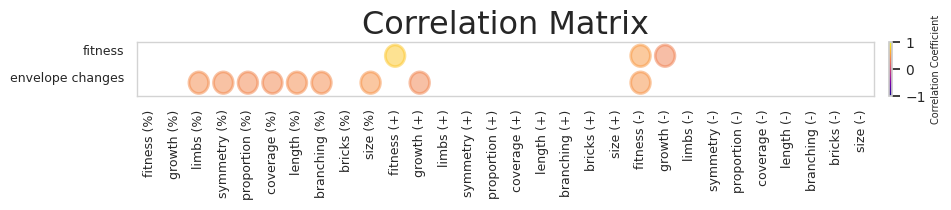

>> reg2m2


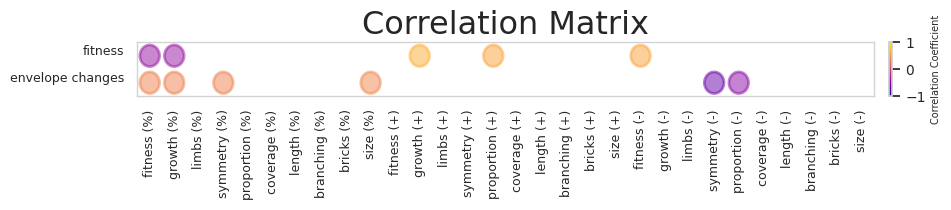

In [71]:
### CORRELATIONS: EPISTASIS VS PHENOCOMPLEXITY

df_complexity_end = df_complexity_all[(df_complexity_all['gen'] == 100)]

metrics1 = ['complexity_env', 'disp_y'] 
additional_columns = []
metrics2 = []
metrics2_adjusted = []
metrics1_adjusted = [  'envelope changes', 'fitness'] 

additional_columns_adjusted = []

for idx,trait in enumerate(traits):

    df_trait = df_traits[trait].copy(deep=True) 
    df_trait = df_trait.drop(columns=['Unnamed: 0'])

    corr_df = pd.merge(df_complexity_end, df_trait, on=keys, how='inner')
    corr_df = corr_df.rename(columns={'epistasis_percent': 'epistasis_percent_'+trait, 
                                      'avg_positive': 'avg_positive_'+trait, 
                                      'avg_negative': 'avg_negative_'+trait})
    metrics2.append('epistasis_percent_'+trait)
    metrics2.append('avg_positive_'+trait)
    metrics2.append('avg_negative_'+trait)
    metrics2_adjusted.append(traits_label[idx]+' (%)')
    metrics2_adjusted.append(traits_label[idx]+ ' (+)')
    metrics2_adjusted.append(traits_label[idx]+ ' (-)')
   
    obsolete_vars = ['symmetry', 'extremities_prop' ,'neutral', 'positive', 'negative', 'epistasis']
    redudant_vars = [ 'ranking', 'disp_y', 'geno_size', 'n_genes' ,'complexity_env',
                     'complexity_branch', 'complexity_net', 'interactions_density', 'zero_regulators']

    if idx == 0:
        corr_df_all = corr_df.drop(columns=obsolete_vars)
    else:
        corr_df = corr_df.drop(columns=obsolete_vars+redudant_vars)
        corr_df_all = pd.merge(corr_df_all, corr_df, on=keys, how='inner')
  
for idx_experiment, exp in enumerate(experiments):
    print('>>', exp)
    df_complexity_end_exp = corr_df_all[(corr_df_all['experiment_name'] == exp)]
    df_complexity_end_exp = df_complexity_end_exp[ (df_complexity_end_exp['ranking'] == 'best') ] 
    df_complexity_end_exp[df_complexity_end_exp.select_dtypes(include=['number']).columns] = \
                df_complexity_end_exp.select_dtypes(include=['number']).fillna(0)

    def darken_color(color, factor=0.5):
        r, g, b, a = mcolors.to_rgba(color)
        return mcolors.to_hex((r * factor, g * factor, b * factor, a))
    
    # Function to calculate correlation and p-values
    def calculate_corr_and_pvalues(df):
        corr_matrix = df.corr()
        p_values = pd.DataFrame(np.zeros_like(corr_matrix, dtype=float), index=corr_matrix.index, columns=corr_matrix.columns)
        
        for i in range(len(corr_matrix.columns)):
            for j in range(len(corr_matrix.columns)):
                if i != j:
                    corr, p_value = stats.pearsonr(df.iloc[:, i], df.iloc[:, j])
                    p_values.iloc[i, j] = p_value
                    if p_value < 0.05:
                        pass
                        #print(corr_matrix.columns[i], corr_matrix.columns[j], corr, p_value)
                else:
                    p_values.iloc[i, j] = np.nan  # No p-value for self-correlation
    
        return corr_matrix, p_values
    


    # Compute correlations and p-values
    corr_matrix, p_values = calculate_corr_and_pvalues(df_complexity_end_exp[metrics1 + metrics2])
    
    original_names = metrics1 + metrics2 + additional_columns
    adjusted_names = metrics1_adjusted + metrics2_adjusted + additional_columns_adjusted
    rename_mapping = {original: adjusted for original, adjusted in zip(original_names, adjusted_names)}
    
    corr_matrix = corr_matrix.rename(columns=rename_mapping, index=rename_mapping)
    p_values = p_values.rename(columns=rename_mapping, index=rename_mapping)
    
    # Reorder metrics2_adjusted
    percent_labels = [label for label in metrics2_adjusted if '(%)' in label]
    plus_labels = [label for label in metrics2_adjusted if '(+)' in label]
    minus_labels = [label for label in metrics2_adjusted if '(-)' in label]
    
    metrics2_adjusted_sorted = percent_labels + plus_labels + minus_labels + additional_columns_adjusted
    
    # Select the relevant portion of the correlation matrix with reordered x-axis
    corr_matrix = corr_matrix.loc[metrics1_adjusted, metrics2_adjusted_sorted]
    p_values = p_values.loc[metrics1_adjusted, metrics2_adjusted_sorted]
    
    # Create a mask for significant correlations
    significance_mask = p_values < 0.05

    
    # Create a color map from blue to red
    cmap = mcolors.LinearSegmentedColormap.from_list(
        'blue_red',
        ['blue', 'white', 'red'],
        N=256
    )
    cmap = plt.get_cmap('plasma')
    
    # Plotting ########
    plt.figure(figsize=(10, 0.7))
    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_edgecolor('#D3D3D3')   # Set the color for all spines
        spine.set_linewidth(1) 
    
    # Draw the circles for significant correlations
    for i in range(corr_matrix.shape[0]):
        for j in range(corr_matrix.shape[1]):
            if significance_mask.iloc[i, j]:

                rect_color = cmap((corr_matrix.iloc[i, j] + 1) / 2)  # Normalize correlation to [0, 1]
                border_color = darken_color(rect_color, factor=0.7)  # Darken the fill color for border

                rect = plt.Circle((j, i),  0.40, color=rect_color, alpha=0.5, edgecolor=border_color, linewidth=2, zorder=10)
                ax.add_patch(rect)
             #   plt.text(j , i + 0.2, f'{corr_matrix.iloc[i, j]:.2f}', color='black',     ha='center', va='center', fontsize=6, zorder=20)

    # Set the labels and limits
    plt.xticks(ticks=np.arange(len(corr_matrix.columns)) , labels=corr_matrix.columns, rotation=90, fontsize=9)
    plt.yticks(ticks=np.arange(len(corr_matrix.index))+0.2  , labels=corr_matrix.index, fontsize=9)
   
    plt.xlim(-0.5, len(corr_matrix.columns) - 0.5)
    plt.ylim(len(corr_matrix.index) - 0.5, -0.5)

    plt.title('Correlation Matrix')
    plt.grid(False)
    plt.gca().invert_yaxis()

    # Create and add color bar
    norm = mcolors.Normalize(vmin=-1, vmax=1)  # Adjust vmin and vmax according to your data
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, orientation='vertical', fraction=0.03, pad=0.02)
    cbar.ax.tick_params(labelsize=10)
    cbar.set_label('Correlation Coefficient', fontsize=7)
    
    plt.savefig(f'{path}/knockouts/corr_{exp}.png', dpi=300, bbox_inches='tight')
    plt.show()


In [ ]:

### epistais vs fit


metrics_dist = ['disp_y']
metrics_order = ['avg_positive_disp_y', 'avg_negative_disp_y','epistasis_percent_disp_y' ]

for metric_dist in metrics_dist:
    print(f'\n >>>>> metrics_dist',metric_dist)
    for metric_order in metrics_order:
        print(f'\n   >>> metric_order',metric_order)
        for exp in experiments:
            print('\n --',exp)
            df_comp_g = corr_df_all[ (corr_df_all['experiment_name'] == exp) ] 
            df_comp_g[df_comp_g.select_dtypes(include=['number']).columns] = \
                    df_comp_g.select_dtypes(include=['number']).fillna(0)
            df_comp_g = df_comp_g[ (df_comp_g['ranking'] == 'best') ] 
            df_sorted = df_comp_g.sort_values(by=metric_order).reset_index(drop=True)
                   
    
            midpoint = len(df_sorted) // 2
            first_half = df_sorted.iloc[:midpoint]
            second_half = df_sorted.iloc[midpoint:]
            
            # Calculate and display the averages for 'b' in each half
            avg_first_half = first_half[metric_dist].mean()
            avg_second_half = second_half[metric_dist].mean()
     
            print(f"Average first : {avg_first_half}")
            print(f"Average second : {avg_second_half}")
            
            t_stat, p_value = ttest_ind(first_half[metric_dist], second_half[metric_dist], equal_var=True)
    
            #_, p_value = mannwhitneyu(first_half[metric_dist], second_half[metric_dist], alternative='two-sided')
            print(f"  p-value: {round(p_value, 4)}")
            
            # Add a new column to each half to indicate "First Half" or "Second Half"
            first_half['half'] = 'First'
            second_half['half'] = 'Second'
            
            #  Concatenate the two halves back into a single DataFrame
            df_concat = pd.concat([first_half, second_half], ignore_index=True)
            
            # Plot variable 'disp_y' for each half using box plots
            plt.figure(figsize=(4, 4))
            sb.boxplot(x='half', y=metric_dist, data=df_concat, palette="Set2")
            
            plt.scatter(x=[0], y=[avg_first_half], color='red', label='Mean', zorder=5)
            plt.scatter(x=[1], y=[avg_second_half], color='red', zorder=5)
            
            plt.title(' ')
            plt.ylabel('' )
            plt.show() 


In [ ]:
### EPISTASIS CATEG CHANGES ###
traits = ['disp_y', 'distance' ]

metrics = ['buffering', 'suppression', 'quantitative_buffering', 'quantitative_suppression', 'masking', 'inversion']

clrs = ['#009900',

        
        '#EE8610']

avg_pos_scale = {'disp_y': [-0.5, 4],'extremities_prop': [-0.05, 1.1],'symmetry': [-0.05, 1.15], 'distance': [-0.5, 25]}

sb.set(rc={"axes.titlesize": 23, "axes.labelsize": 23, 'ytick.labelsize': 21, 'xtick.labelsize': 21})
sb.set_style("whitegrid")

for trait in traits:
    print('>>>>>',trait)
    df_trait = df_categ_traits[trait].copy(deep=True)
    
    for exp in experiments:
        print('>>',exp)
        df_trait_exp = df_trait[df_trait['experiment_name'] == exp]
        df_trait_exp = df_trait_exp[ (df_trait_exp['ranking'] == 'best') ] 
   
        df_trait_exp_zero = df_trait_exp[ (df_trait_exp['epistasis'] == 0) ] 
        df_trait_exp = df_trait_exp[ (df_trait_exp['epistasis'] > 0) ] 
       
        df_trait_exp[metrics] = df_trait_exp[metrics].fillna(0)
        
        fig, axes = plt.subplots(1, 7, figsize=(15, 5))  #
       
        for idx, metric in enumerate(metrics):
            ax = axes[idx]

            filtered_clean = df_trait_exp[pd.notna(df_trait_exp[metric])]
            ini_gen = filtered_clean[filtered_clean['gen'] == 0][f'{metric}']
            end_gen = filtered_clean[filtered_clean['gen'] == 100][f'{metric}']

            _, p_value = mannwhitneyu(ini_gen, end_gen, alternative='two-sided')
            #print(f"\nMetric: {metric}, p-value: {round(p_value, 4)}")

            sb.boxplot(x='gen', y=f'{metric}', data=filtered_clean,
                       palette=clrs, width=0.4, showmeans=True, linewidth=2, fliersize=6,
                       meanprops={"marker": "o", "markerfacecolor": "yellow", "markersize": "12"}, ax=ax)
    
            y_max = filtered_clean[f'{metric}'].max() + 0.05             
            x_positions = [0, 1]  
            ax.plot(x_positions, [y_max, y_max], color='black', linestyle='--', linewidth=1)
            if p_value >= 0.05:
                sig = 'NS'
                alpha = 0.2
                for patch in ax.patches:
                    patch.set_alpha(alpha)
                    patch.set_edgecolor((0.0, 0.0, 0.0, alpha))  # Example RGBA border color
                for line in ax.lines:
                    if line.get_linestyle() == '-' or line.get_linestyle() == '--':
                        line.set_color((0.0, 0.0, 0.0, alpha))  
                 
            else:
                sig = f'p={p_value:.4f}'
            ax.text(x=0.5, y=y_max, s=sig, ha='center', va='bottom', fontsize=10)
      
            ax.tick_params(axis='x', labelrotation=10)
            ax.set_xlabel('')
            ax.set_ylabel(f'{metric}')


        ax = axes[idx+1]

        # Create a bar plot to count the number of rows for each 'gen'
        sb.countplot(x='gen', data=df_trait_exp_zero, palette=clrs, linewidth=2, ax=ax)
        
        # Customize the plot
        ax.tick_params(axis='x', labelrotation=10)
        ax.set_xlabel('')
        ax.set_ylabel(f'Count of non epi')
        ax.set_ylim(0, 25) 
        
        # Adjust the layout and display the plot
        plt.tight_layout()
        plt.show()
    


In [ ]:
# Create a figure for the grid
fig, ax = plt.subplots(len(traits), len(metrics), figsize=(7, 1.5), constrained_layout=True)

for i, trait in enumerate(traits):
    df_trait = df_categ_traits[trait].copy(deep=True)
    for j, metric in enumerate(metrics):
        for k, exp in enumerate(experiments):
            df_trait_exp = df_trait[df_trait['experiment_name'] == exp]
            df_trait_exp = df_trait_exp[df_trait_exp['ranking'] == 'best']

            filtered_clean = df_trait_exp[pd.notna(df_trait_exp[metric])]
            ini_gen = filtered_clean[filtered_clean['gen'] == 0][f'{metric}']
            end_gen = filtered_clean[filtered_clean['gen'] == 100][f'{metric}']

            # Calculate the averages
            avg_ini_gen = ini_gen.mean()
            avg_end_gen = end_gen.mean()

            # Perform the Mann-Whitney U test
            _, p_value = mannwhitneyu(ini_gen, end_gen, alternative='two-sided')
         
            # Calculate the ratio of gen 100 to gen 0
            ratio = (avg_end_gen / avg_ini_gen) * 100
            #print(trait, metric, exp, avg_ini_gen, avg_ini_gen,ratio , p_value)

            min_old, max_old = 6, 878
            min_new, max_new = 15, 40
            
            # Normalize the variable from [6, 2000] to [10, 60]
            arrow_zize = ((ratio- min_old) / (max_old - min_old)) * (max_new - min_new) + min_new

            # Determine the subcell width and x-position for horizontal stacking
            subcell_width = 1.0 / len(experiments)
            x_position = k * subcell_width

            if (ratio == np.inf or ratio == -np.inf)  :# and not(np.isnan(ratio)):
                ax[i, j].annotate('+', xy=(x_position + subcell_width / 2, 0.35), xytext=(x_position + subcell_width / 2, 0.35),
                  textcoords='axes fraction', alpha=alpha, ha='center', va='center', color='green', fontsize=10, fontweight='bold',
                  path_effects=[path_effects.withStroke(linewidth=1, foreground='black')])
                
            if p_value >= 0.05:
                alpha = 1
                border = 1
            else:
                alpha = 1
                border = 2

            display_text = f'{ratio:.0f}%'
            
            if ratio > 100:
                if p_value >= 0.05:
                    a_color = 'white'
                else:
                    a_color = 'green'
                    
                # Green arrow pointing up, below the text
              #  ax[i, j].text(x_position + subcell_width / 2, 0.65, display_text, ha='center', va='center', fontsize=12, color='black')
                ax[i, j].annotate('↑', xy=(x_position + subcell_width / 2, 0.35), xytext=(x_position + subcell_width / 2, 0.35),
                                  textcoords='axes fraction', alpha=alpha, ha='center', va='center', color=a_color, fontsize=arrow_zize, fontweight='bold',
                                  path_effects=[path_effects.withStroke(linewidth=border, foreground='black')])
            else:
                if p_value >= 0.05:
                    a_color = 'white'
                else:
                    a_color = 'red'
                # Red arrow pointing down, above the text
              #  ax[i, j].text(x_position + subcell_width / 2, 0.35, display_text, ha='center', va='center', fontsize=12, color='black')
                ax[i, j].annotate('↓', xy=(x_position + subcell_width / 2, 0.35), xytext=(x_position + subcell_width / 2, 0.35),
                                  textcoords='axes fraction',  alpha=alpha, ha='center', va='center', color=a_color, fontsize=arrow_zize, fontweight='bold',
                                  path_effects=[path_effects.withStroke(linewidth=border, foreground='black')])

            # Draw the borders for each metric cell and subcells
            ax[i, j].spines['top'].set_visible(False)
            ax[i, j].spines['right'].set_visible(False)
            ax[i, j].spines['bottom'].set_visible(True)
            ax[i, j].spines['left'].set_visible(True)        

            # Draw the borders for the subcells
            ax[i, j].add_patch(plt.Rectangle((x_position, 0), subcell_width, 1, fill=False, edgecolor='white', lw=0.5))

        # Set the grid borders
        ax[i, j].set_xticks([])
        ax[i, j].set_yticks([])

# Set row labels for traits
# for i, trait in enumerate(traits):
#     ax[i, 0].set_ylabel(trait, fontsize=8, rotation=90, labelpad=30, ha='right')

plt.show()
fig.savefig(f'{path}/knockouts/epistasis_categ_change.png', dpi=300, bbox_inches='tight')


In [ ]:

metrics = ['buffering', 'suppression', 'quantitative_buffering', 'quantitative_suppression', 'masking', 'inversion']

clrs = ['#009900', '#EE8610']

avg_pos_scale = {'disp_y': [-0.5, 4], 'extremities_prop': [-0.05, 1.1], 'symmetry': [-0.05, 1.15], 'distance': [-0.5, 25]}


sb.set_style("whitegrid")

for trait in traits:
   # print('>>>>>', trait)
    df_trait = df_categ_traits[trait].copy(deep=True)
    
    for exp in experiments:
     #   print('>>', exp)
        df_trait_exp = df_trait[df_trait['experiment_name'] == exp]
        df_trait_exp = df_trait_exp[df_trait_exp['ranking'] == 'best']
        
        df_trait_exp_zero = df_trait_exp[df_trait_exp['epistasis'] == 0]
        
        # Count the number of rows in df_trait_exp_zero
        num_rows = df_trait_exp_zero.shape[0]
        #print(f'The number of rows in df_trait_exp_zero is: {num_rows}')
        
        if num_rows > 0:
            fig, ax = plt.subplots(1, 1, figsize=(2, 2))

            # Create countplot
            sb.countplot(x='gen', data=df_trait_exp_zero, palette=clrs, linewidth=2, ax=ax)

            # Remove x-axis labels
            ax.set_xticklabels([''] * len(ax.get_xticks()))

            # Consistent bar width
            for patch in ax.patches:
                patch.set_width(0.4)  # Adjust width to keep it consistent

            # Add a dummy bar if there's only one bar
            if len(ax.patches) == 1:
                ax.bar(1, 0, width=0.4, color='white', edgecolor='white')  # Invisible bar to maintain spacing

            # Remove y-axis labels
            ax.set_yticklabels([])
            ax.set_xlabel('')
            ax.set_ylabel('')

            # Set y-axis limit
            ax.set_ylim(0, 25)
            
            # Adjust the layout and display the plot
            plt.tight_layout()
            ax.grid(False)
            plt.show()
            
            fig.savefig(f'{path}/knockouts/epistasis_nochange_{trait}_{exp}.png', dpi=300, bbox_inches='tight')

In [ ]:
### CORRELATIONS: CATEG EPISTASIS VS PHENOCOMPLEXITY
metrics1 = [ 'complexity_env', 'disp_y']
additional_columns = [] 
metrics2 = []

metrics1_adjusted = [ 'envelope changes',  'fitness']
metrics2_adjusted = ['fitness (B)', 'growth (B)',  
                     'fitness (S)', 'growth (S)',
                     'fitness (QB)', 'growth (QB)',
                     'fitness (QS)', 'growth (QS)', 
                     'fitness (M)',  'growth (M)', 
                     'fitness (I)', 'growth (I)',
                    ]
additional_columns_adjusted = []

categs = ['buffering', 'suppression' , 'quantitative_buffering', 'quantitative_suppression', 'masking', 'inversion'] 

for idx,trait in enumerate(traits):
    df_trait = df_categ_traits[trait].copy(deep=True) 
    df_trait = df_trait.drop(columns=['Unnamed: 0'])

    corr_df = pd.merge(df_complexity_end, df_trait, on=keys, how='inner')

    for categ in categs:
        corr_df = corr_df.rename(columns={categ: f'{categ}_'+trait    })
        
    obsolete_vars = ['symmetry', 'extremities_prop' , 'epistasis']
    redudant_vars = [ 'ranking', 'disp_y', 'geno_size', 'n_genes', 'complexity_env',
                     'complexity_branch', 'complexity_net', 'interactions_density']

    if idx == 0:
        corr_df_all = corr_df.drop(columns=obsolete_vars)
    else:
        corr_df = corr_df.drop(columns=obsolete_vars+redudant_vars)
        corr_df_all = pd.merge(corr_df_all, corr_df, on=keys, how='inner')

metrics2 = []
for categ in categs:
  for idx,trait in enumerate(traits):
      metrics2.append(f'{categ}_' + trait )

for idx_experiment, exp in enumerate(experiments):
    print('>>', exp)
    df_complexity_end_exp = corr_df_all[(corr_df_all['experiment_name'] == exp)]
    df_complexity_end_exp = df_complexity_end_exp[ (df_complexity_end_exp['ranking'] == 'best') ] 
    df_complexity_end_exp[df_complexity_end_exp.select_dtypes(include=['number']).columns] = df_complexity_end_exp.select_dtypes(include=['number']).fillna(0)

    def darken_color(color, factor=0.7):
        r, g, b, a = mcolors.to_rgba(color)
        return mcolors.to_hex((r * factor, g * factor, b * factor, a))
    
    # Function to calculate correlation and p-values
    def calculate_corr_and_pvalues(df):
        corr_matrix = df.corr()
        p_values = pd.DataFrame(np.zeros_like(corr_matrix, dtype=float), index=corr_matrix.index, columns=corr_matrix.columns)
        
        for i in range(len(corr_matrix.columns)):
            for j in range(len(corr_matrix.columns)):
                if i != j:
                    corr, p_value = stats.pearsonr(df.iloc[:, i], df.iloc[:, j])
                    p_values.iloc[i, j] = p_value
                    if p_value < 0.05:
                        pass
                       # print(corr_matrix.columns[i], corr_matrix.columns[j], corr, p_value)
                else:
                    p_values.iloc[i, j] = np.nan  # No p-value for self-correlation
    
        return corr_matrix, p_values
    
    
    # Compute correlations and p-values
    corr_matrix, p_values = calculate_corr_and_pvalues(df_complexity_end_exp[metrics1 + metrics2])
    
    original_names = metrics1 + metrics2 + additional_columns
    adjusted_names = metrics1_adjusted + metrics2_adjusted + additional_columns_adjusted
    rename_mapping = {original: adjusted for original, adjusted in zip(original_names, adjusted_names)}
    corr_matrix = corr_matrix.rename(columns=rename_mapping, index=rename_mapping)
    p_values = p_values.rename(columns=rename_mapping, index=rename_mapping)
    
    #display(corr_matrix)
    
    # Select the relevant portion of the correlation matrix
    corr_matrix = corr_matrix.loc[metrics1_adjusted, metrics2_adjusted + additional_columns_adjusted]
    p_values = p_values.loc[metrics1_adjusted, metrics2_adjusted + additional_columns_adjusted]
    
    # Create a mask for significant correlations
    significance_mask = p_values < 0.05
    
    # Create a color map from blue to red
    cmap = plt.get_cmap('plasma')

    # Plotting
    plt.figure(figsize=(7, 2.5))
    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_edgecolor('#D3D3D3')
        spine.set_linewidth(1)
        
    
    # Draw the circles for significant correlations
    for i in range(corr_matrix.shape[0]):
        for j in range(corr_matrix.shape[1]):
            if significance_mask.iloc[i, j]:
                rect_color = cmap((corr_matrix.iloc[i, j] + 1) / 2)  # Normalize correlation to [0, 1]
                border_color = darken_color(rect_color, factor=0.7)  # Darken the fill color for border

                rect = plt.Circle((j, i),  0.30, color=rect_color, alpha=0.5, edgecolor=border_color, linewidth=2, zorder=10)
                ax.add_patch(rect)
                # show coefficients
                #plt.text(j , i , f'{corr_matrix.iloc[i, j]:.2f}', color='black', ha='center', va='center', fontsize=10, zorder=20)

    # Set the labels and limits
    plt.xticks(ticks=np.arange(len(corr_matrix.columns)) , labels=corr_matrix.columns, rotation=90, fontsize=11)
    plt.yticks(ticks=np.arange(len(corr_matrix.index))+0.2  , labels=corr_matrix.index, fontsize=11)
   
    plt.xlim(-0.5, len(corr_matrix.columns) - 0.5)
    plt.ylim(len(corr_matrix.index) - 0.5, -0.5)

    plt.title('Correlation Matrix')
    plt.grid(False)
    plt.gca().invert_yaxis()

    # Create and add color bar
    norm = mcolors.Normalize(vmin=-1, vmax=1)  # Adjust vmin and vmax according to your data
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, orientation='vertical', fraction=0.03, pad=0.02)
    cbar.ax.tick_params(labelsize=11)
    cbar.set_label('Correlation Coefficient', fontsize=11)
    plt.tight_layout()

    plt.savefig(f'{path}/knockouts/corr_categ_{exp}.png', dpi=300, bbox_inches='tight')
    plt.show()



In [ ]:

### COMPLEXITY AND GENO SIZE PROGRESSION

grouped = df_complexity_all.groupby(['experiment_name', 'run', 'gen'])
df_complexity_inner = grouped.agg({
    'geno_size': 'mean',
    'complexity_branch': 'mean',
    'complexity_env': 'mean',
    'n_genes': 'mean',
    'interactions_density': 'mean',
    'zero_regulators': 'mean'
})
df_complexity_inner = df_complexity_inner.reset_index()

q1 = lambda x: x.quantile(0.25)
q3 = lambda x: x.quantile(0.75)

grouped = df_complexity_inner.groupby(['experiment_name', 'gen'])
df_complexity_outer = grouped.agg({
    'geno_size': ['median', q1, q3],
    'complexity_branch': ['median', q1, q3],
    'complexity_env': ['median', q1, q3],
    'n_genes': ['median', q1, q3],
    'interactions_density': ['median', q1, q3],
    'zero_regulators': ['median', q1, q3]
})
df_complexity_outer.columns = [
    ('geno_size', 'median'), ('geno_size', 'Q1'), ('geno_size', 'Q3'),
    ('complexity_branch', 'median'), ('complexity_branch', 'Q1'), ('complexity_branch', 'Q3'),
    ('complexity_env', 'median'), ('complexity_env', 'Q1'), ('complexity_env', 'Q3'),
    ('n_genes', 'median'), ('n_genes', 'Q1'), ('n_genes', 'Q3'),
    ('interactions_density', 'median'), ('interactions_density', 'Q1'), ('interactions_density', 'Q3'),
    ('zero_regulators', 'median'), ('zero_regulators', 'Q1'), ('zero_regulators', 'Q3')
]
df_complexity_outer.columns = ['_'.join(col) for col in df_complexity_outer.columns]
df_complexity_outer = df_complexity_outer.reset_index()

clrs = ['#ADD8E6',
        '#F6B970']
traits_labels = ['Genome Size', 'Number of Genes', 'Interaction Density', 'Average Branching', 'Envelope Changes', 'Non Regulatod']

metrics = ['geno_size', 'n_genes', 'interactions_density', 'complexity_branch', 'complexity_env','zero_regulators']
for idm, metric in enumerate(metrics):

    font = {'font.size': 20}
    plt.rcParams.update(font)
    fig, ax = plt.subplots()#figsize=(3,2))

    plt.xlabel('')
    plt.ylabel(f'{traits_labels[idm]}')
    ax.grid(False)
    ax.spines['top'].set_color('grey')
    ax.spines['top'].set_linewidth(0.5)
    ax.spines['right'].set_color('grey')
    ax.spines['right'].set_linewidth(0.5)
    ax.spines['bottom'].set_color('grey')
    ax.spines['bottom'].set_linewidth(0.5)
    ax.spines['left'].set_color('grey')
    ax.spines['left'].set_linewidth(0.5)
    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=True)
    ax.tick_params(axis='y', which='both', left=False, right=False, labelleft=True)


    for idx_experiment, exp in enumerate(experiments):
        metric_exp = df_complexity_outer[df_complexity_outer['experiment_name'] == exp]
        
        ax.plot(metric_exp['gen'], metric_exp[f'{metric}_median'],
                    label=f'{exp}', c=clrs[idx_experiment], linewidth=3)
        
        ax.fill_between(metric_exp['gen'],
                        metric_exp[f'{metric}_Q1'],
                        metric_exp[f'{metric}_Q3'],
                        alpha=0.4, facecolor=clrs[idx_experiment])
        
        ax.plot(metric_exp['gen'],
        metric_exp[f'{metric}_Q1'],
        linestyle='-', color=clrs[idx_experiment], alpha=0.5, linewidth=1.5)  # Contour line for Q1

        ax.plot(metric_exp['gen'],
        metric_exp[f'{metric}_Q3'],
        linestyle='-', color=clrs[idx_experiment], alpha=0.5, linewidth=1.5)  # Contour line for Q3

        
        ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1),  fancybox=True, shadow=True, ncol=5, fontsize=10)

    plt.show()
    plt.clf()
    fig.savefig(f'{path}/knockouts/{metric}.png', dpi=300, bbox_inches='tight')
    plt.close(fig)

    group1_data = df_complexity_inner[(df_complexity_inner['experiment_name'] == 'reg10m2') & (df_complexity_inner['gen'] == 100) ][f'{metric}']
    group2_data = df_complexity_inner[(df_complexity_inner['experiment_name'] == 'reg2m2') & (df_complexity_inner['gen'] == 100) ][f'{metric}']
    _, p_value = mannwhitneyu(group1_data, group2_data, alternative='two-sided')
    print(metric, ':', group1_data.median(), group2_data.median(), p_value)



In [ ]:

### FIT VS GENOSIZE 


metrics_dist = ['disp_y']
metrics_order = ['n_genes']

for metric_dist in metrics_dist:
    print('\n >>>>>',metric_dist)
    for metric_order in metrics_order:
        print('\n >>>',metric_order)
        for exp in experiments:
            print('\n --',exp)
            df_comp_g = corr_df_all[ (corr_df_all['experiment_name'] == exp) ] 
            df_comp_g = df_comp_g[ (df_comp_g['ranking'] == 'best') ] 
            df_sorted = df_comp_g.sort_values(by=metric_order).reset_index(drop=True)
            display(df_sorted)
        
    
            midpoint = len(df_sorted) // 2
            first_half = df_sorted.iloc[:midpoint]
            second_half = df_sorted.iloc[midpoint:]
            
            # Calculate and display the averages for 'b' in each half
            avg_first_half = first_half[metric_dist].mean()
            avg_second_half = second_half[metric_dist].mean()
            #display(first_half)
          #  display(second_half)
            print(f"Average of 'b' in the first : {avg_first_half}")
            print(f"Average of 'b' in the second : {avg_second_half}")
            
            t_stat, p_value = ttest_ind(first_half[metric_dist], second_half[metric_dist], equal_var=True)
           # _, p_value = wilcoxon(first_half[metric_dist], second_half[metric_dist])
            #_, p_value = mannwhitneyu(first_half[metric_dist], second_half[metric_dist], alternative='two-sided')
            print(f"  p-value: {round(p_value, 4)}")
            
            # Add a new column to each half to indicate "First Half" or "Second Half"
            first_half['half'] = 'First'
            second_half['half'] = 'Second'
            
            #  Concatenate the two halves back into a single DataFrame
            df_concat = pd.concat([first_half, second_half], ignore_index=True)
            
            # Plot variable 'disp_y' for each half using box plots
            plt.figure(figsize=(4, 4))
            sb.boxplot(x='half', y=metric_dist, data=df_concat, palette="Set2")
            
            plt.scatter(x=[0], y=[avg_first_half], color='red', label='Mean', zorder=5)
            plt.scatter(x=[1], y=[avg_second_half], color='red', zorder=5)
            
            plt.title(' ')
            plt.ylabel('' )
            plt.show() 



### FIT VS GENOSIZE 



metrics_dist = ['complexity_env']
metrics_order = ['disp_y']

for metric_dist in metrics_dist:
    print('\n >>>>>',metric_dist)
    for metric_order in metrics_order:
        print('\n >>>',metric_order)
     
        df_comp_g = df_comp_g[ (corr_df_all['ranking'] == 'best') ] 
        df_sorted = df_comp_g.sort_values(by=metric_order).reset_index(drop=True)


        midpoint = len(df_sorted) // 2
        first_half = df_sorted.iloc[:midpoint]
        second_half = df_sorted.iloc[midpoint:]
        
        # Calculate and display the averages for 'b' in each half
        avg_first_half = first_half[metric_dist].mean()
        avg_second_half = second_half[metric_dist].mean()
        #display(first_half)
      #  display(second_half)
        print(f"Average of 'b' in the first : {avg_first_half}")
        print(f"Average of 'b' in the second : {avg_second_half}")
        
        t_stat, p_value = ttest_ind(first_half[metric_dist], second_half[metric_dist], equal_var=True)
       # _, p_value = wilcoxon(first_half[metric_dist], second_half[metric_dist])
        #_, p_value = mannwhitneyu(first_half[metric_dist], second_half[metric_dist], alternative='two-sided')
        print(f"  p-value: {round(p_value, 4)}")
        
        # Add a new column to each half to indicate "First Half" or "Second Half"
        first_half['half'] = 'First'
        second_half['half'] = 'Second'
        
        #  Concatenate the two halves back into a single DataFrame
        df_concat = pd.concat([first_half, second_half], ignore_index=True)
        
        # Plot variable 'disp_y' for each half using box plots
        plt.figure(figsize=(4, 4))
        sb.boxplot(x='half', y=metric_dist, data=df_concat, palette="Set2")
        
        plt.scatter(x=[0], y=[avg_first_half], color='red', label='Mean', zorder=5)
        plt.scatter(x=[1], y=[avg_second_half], color='red', zorder=5)
        
        plt.title(' ')
        plt.ylabel('' )
        plt.show() 

